In [1]:
!pip install pandas numpy matplotlib scikit-learn 

# Probability Distributions in AI/ML - Practice Notebook

This notebook contains conceptual and coding questions on Normal, Binomial, and Poisson distributions.

---

## 1. Normal Distribution

**Q1:** Generate a normal distribution with mean=0 and std=1. Plot it.

**Q2:** Simulate exam scores of 1000 students assuming normal distribution. What percentage scored above 85?

**Q3 (Thinking):** How does changing standard deviation affect the spread? Visualize.

In [2]:
!pip install numpy matplotlib scipy
# or
!pip install numpy matplotlib seaborn

**Q1:** Generate a normal distribution with mean=0 and std=1. Plot it.

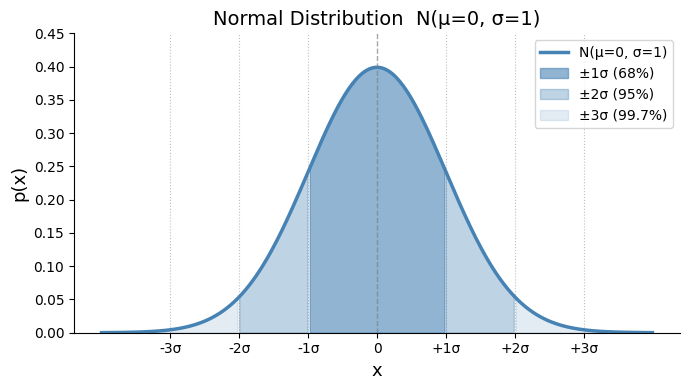

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Data ---
x = np.linspace(-4, 4, 300)
y = norm.pdf(x, loc=0, scale=1)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4))

# Curve
ax.plot(x, y, color='steelblue', linewidth=2.5, label='N(μ=0, σ=1)')

# Shaded sigma bands
ax.fill_between(x, y, where=(np.abs(x) <= 1),
                alpha=0.6, color='steelblue', label='±1σ (68%)')
ax.fill_between(x, y, where=(np.abs(x) <= 2) & (np.abs(x) > 1),
                alpha=0.35, color='steelblue', label='±2σ (95%)')
ax.fill_between(x, y, where=(np.abs(x) <= 4) & (np.abs(x) > 2),
                alpha=0.15, color='steelblue', label='±3σ (99.7%)')

# Mean line
ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Sigma tick lines
for s in [-3, -2, -1, 1, 2, 3]:
    ax.axvline(s, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

# Labels & formatting
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('p(x)', fontsize=13)
ax.set_title('Normal Distribution  N(μ=0, σ=1)', fontsize=14)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_xticklabels(['-3σ', '-2σ', '-1σ', '0', '+1σ', '+2σ', '+3σ'])
ax.set_ylim(0, 0.45)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('normal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Q2:** Simulate exam scores of 1000 students assuming normal distribution. What percentage scored above 85?

Total students      : 1000
Scored above 85     : 98
Percentage above 85 : 9.80%


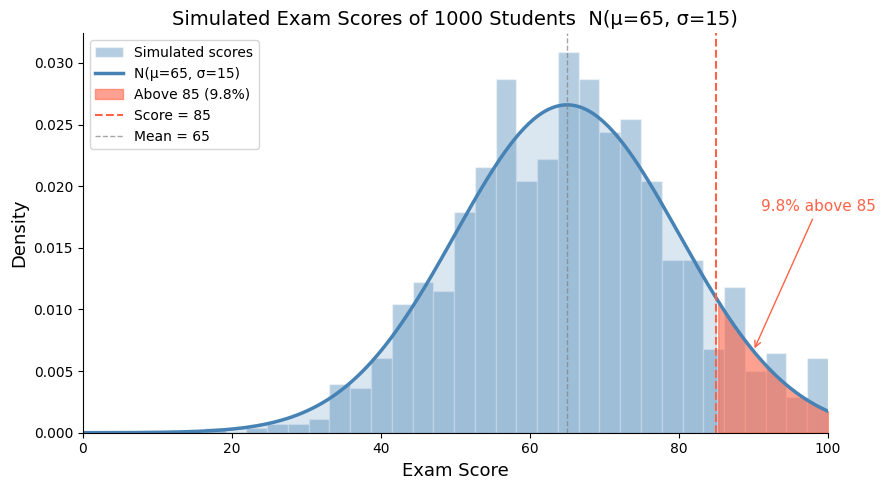

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Simulate ---
np.random.seed(42)
mean, std = 65, 15
scores = np.random.normal(loc=mean, scale=std, size=1000)
scores = np.clip(scores, 0, 100)  # keep scores in valid range

# --- Analysis ---
above_85 = np.sum(scores > 85)
percent_above_85 = (above_85 / len(scores)) * 100

print(f"Total students      : {len(scores)}")
print(f"Scored above 85     : {above_85}")
print(f"Percentage above 85 : {percent_above_85:.2f}%")

# --- Plot ---
x = np.linspace(0, 100, 300)
y = norm.pdf(x, loc=mean, scale=std)

fig, ax = plt.subplots(figsize=(9, 5))

# Histogram of simulated scores
ax.hist(scores, bins=30, density=True, color='steelblue',
        alpha=0.4, edgecolor='white', label='Simulated scores')

# Fitted normal curve
ax.plot(x, y, color='steelblue', linewidth=2.5, label=f'N(μ={mean}, σ={std})')

# Shade: scored above 85
ax.fill_between(x, y, where=(x > 85),
                alpha=0.6, color='tomato', label=f'Above 85 ({percent_above_85:.1f}%)')

# Shade: scored 85 and below
ax.fill_between(x, y, where=(x <= 85),
                alpha=0.2, color='steelblue')

# Threshold line
ax.axvline(85, color='tomato', linestyle='--', linewidth=1.5, label='Score = 85')

# Mean line
ax.axvline(mean, color='gray', linestyle='--', linewidth=1, alpha=0.7, label=f'Mean = {mean}')

# Annotation
ax.annotate(f'{percent_above_85:.1f}% above 85',
            xy=(90, norm.pdf(90, mean, std)),
            xytext=(91, 0.018),
            fontsize=11, color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato'))

# Formatting
ax.set_xlabel('Exam Score', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Simulated Exam Scores of 1000 Students  N(μ=65, σ=15)', fontsize=14)
ax.set_xlim(0, 100)
ax.set_ylim(0)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('exam_scores.png', dpi=150, bbox_inches='tight')
plt.show()

**Q3 (Thinking):** How does changing standard deviation affect the spread? Visualize.

C:\Users\Ali\AppData\Local\Temp\ipykernel_5584\962879744.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


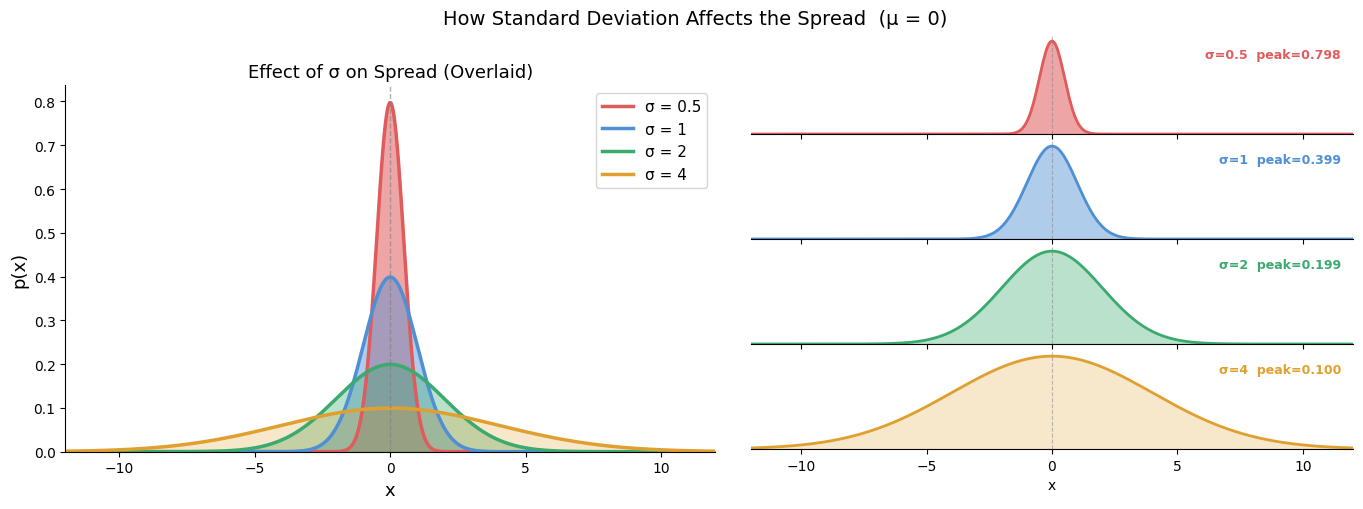

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Setup ---
x = np.linspace(-12, 12, 500)
std_values = [0.5, 1, 2, 4]
colors     = ['#e05c5c', '#4f8fd4', '#3aaa6e', '#e0a030']
alphas     = [0.55, 0.45, 0.35, 0.25]
mean       = 0

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: All curves overlaid ──────────────────────────────────────────────
ax = axes[0]
for std, color, alpha in zip(std_values, colors, alphas):
    y = norm.pdf(x, loc=mean, scale=std)
    ax.plot(x, y, color=color, linewidth=2.5, label=f'σ = {std}')
    ax.fill_between(x, y, alpha=alpha, color=color)

ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('p(x)', fontsize=13)
ax.set_title('Effect of σ on Spread (Overlaid)', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(-12, 12)
ax.set_ylim(0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Right: Separate subplots stacked ──────────────────────────────────────
ax2 = axes[1]
ax2.set_visible(False)  # hide, replace with inset axes

for i, (std, color, alpha) in enumerate(zip(std_values, colors, alphas)):
    # manually place each mini-plot inside axes[1] area
    left = 0.54
    width = 0.43
    row_h = 0.195
    bottom = 0.76 - i * (row_h + 0.015)
    inset = fig.add_axes([left, bottom, width, row_h])

    y = norm.pdf(x, loc=mean, scale=std)
    inset.plot(x, y, color=color, linewidth=2)
    inset.fill_between(x, y, alpha=alpha, color=color)
    inset.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    inset.set_xlim(-12, 12)
    inset.set_ylim(0)
    inset.set_yticks([])
    inset.spines['top'].set_visible(False)
    inset.spines['right'].set_visible(False)
    inset.spines['left'].set_visible(False)

    # Stats annotation
    peak = norm.pdf(0, 0, std)
    inset.text(0.98, 0.78, f'σ={std}  peak={peak:.3f}',
               transform=inset.transAxes,
               ha='right', fontsize=9, color=color, fontweight='bold')

    if i == len(std_values) - 1:
        inset.set_xlabel('x', fontsize=10)

# ── Shared title ──────────────────────────────────────────────────────────
fig.suptitle('How Standard Deviation Affects the Spread  (μ = 0)',
             fontsize=14, y=1.01)

plt.tight_layout()
plt.savefig('std_spread.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Binomial Distribution

**Q4:** Simulate 100 coin toss experiments with probability p=0.5. Plot distribution.

**Q5:** Model a scenario where a student guesses MCQs (4 options). What is probability of getting exactly 6 correct out of 10?

**Q6 (Thinking):** When does binomial start resembling normal distribution? Demonstrate.


#### Q4: Simulate 100 coin toss experiments (p=0.5)


Q4: Coin Toss Simulation
Experiments       : 1000
Tosses each       : 100
Mean heads        : 50.00  (expected 50.0)
Std deviation     : 4.96  (expected 5.00)


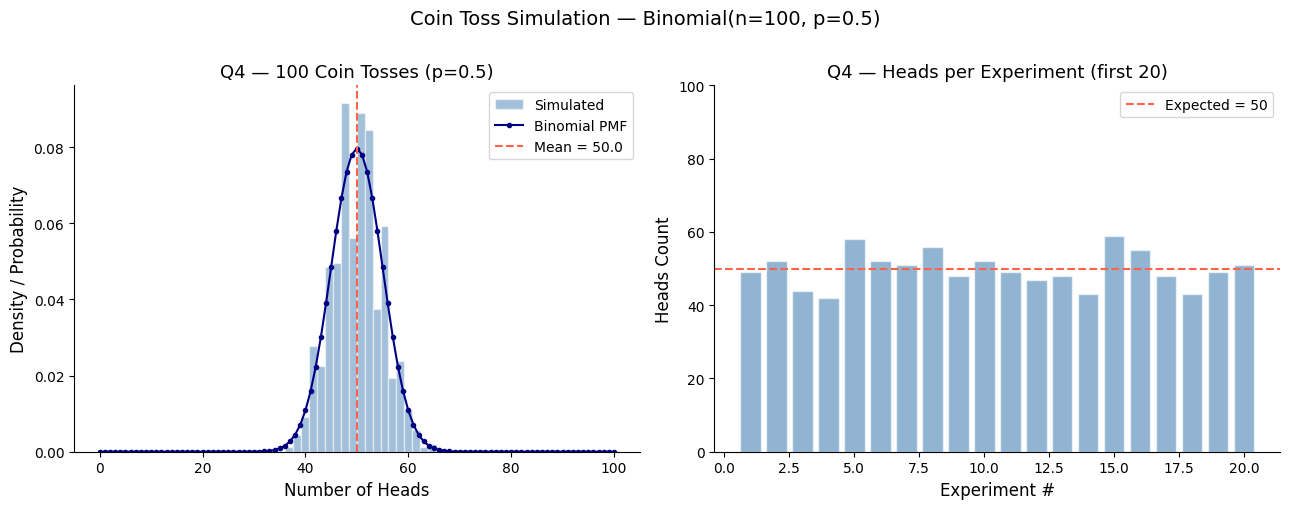

In [ ]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

np.random.seed(42)
n_tosses     = 100   # flips per experiment
p_heads      = 0.5
n_experiments = 1000  # repeat experiment 1000 times

# Simulate: each row = 1 experiment, each col = 1 toss
results   = np.random.binomial(n=n_tosses, p=p_heads, size=n_experiments)
mean_heads = np.mean(results)
std_heads  = np.std(results)

print("=" * 45)
print("Q4: Coin Toss Simulation")
print("=" * 45)
print(f"Experiments       : {n_experiments}")
print(f"Tosses each       : {n_tosses}")
print(f"Mean heads        : {mean_heads:.2f}  (expected {n_tosses*p_heads})")
print(f"Std deviation     : {std_heads:.2f}  (expected {np.sqrt(n_tosses*p_heads*(1-p_heads)):.2f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Histogram of head counts ---
ax = axes[0]
ax.hist(results, bins=20, density=True, color='steelblue',
        alpha=0.5, edgecolor='white', label='Simulated')

# Overlay theoretical binomial PMF
k = np.arange(0, n_tosses + 1)
pmf = binom.pmf(k, n_tosses, p_heads)
ax.plot(k, pmf, 'o-', color='navy', markersize=3,
        linewidth=1.5, label='Binomial PMF')

ax.axvline(mean_heads, color='tomato', linestyle='--',
           linewidth=1.5, label=f'Mean = {mean_heads:.1f}')
ax.set_xlabel('Number of Heads', fontsize=12)
ax.set_ylabel('Density / Probability', fontsize=12)
ax.set_title('Q4 — 100 Coin Tosses (p=0.5)', fontsize=13)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Right: First 20 experiments bar chart ---
ax2 = axes[1]
exp_ids = np.arange(1, 21)
ax2.bar(exp_ids, results[:20], color='steelblue', alpha=0.6, edgecolor='white')
ax2.axhline(50, color='tomato', linestyle='--', linewidth=1.5, label='Expected = 50')
ax2.set_xlabel('Experiment #', fontsize=12)
ax2.set_ylabel('Heads Count', fontsize=12)
ax2.set_title('Q4 — Heads per Experiment (first 20)', fontsize=13)
ax2.set_ylim(0, 100)
ax2.legend(fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Coin Toss Simulation — Binomial(n=100, p=0.5)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('q4_coin_toss.png', dpi=150, bbox_inches='tight')
plt.show()


#### Q5: MCQ guessing — P(exactly 6 correct out of 10)


Q5: MCQ Guessing (n=10, p=0.25)
P(exactly 6 correct) : 0.016222  (1.6222%)
P(6 or fewer correct): 0.996494  (99.6494%)
Expected correct     : 2.5


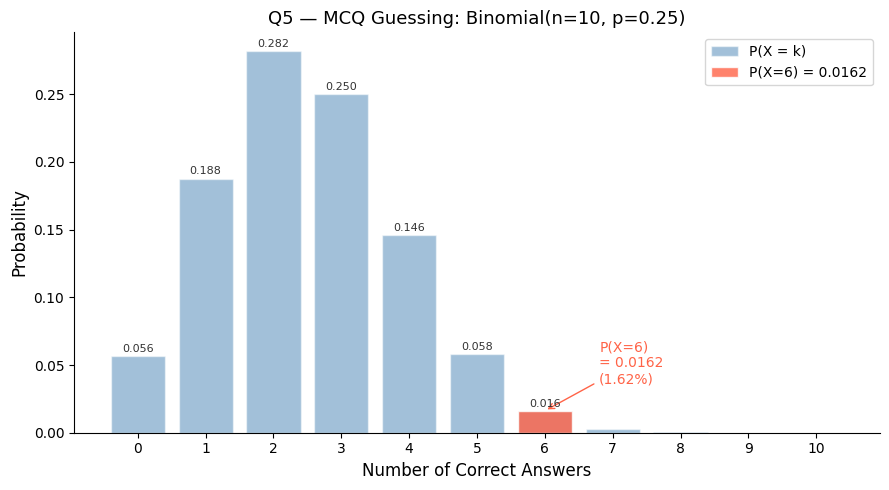

In [7]:

n_questions = 10
p_correct   = 1 / 4   # 4 options, random guess
k_target    = 6

prob_exact = binom.pmf(k_target, n_questions, p_correct)
prob_cum   = binom.cdf(k_target, n_questions, p_correct)

print("\n" + "=" * 45)
print("Q5: MCQ Guessing (n=10, p=0.25)")
print("=" * 45)
print(f"P(exactly 6 correct) : {prob_exact:.6f}  ({prob_exact*100:.4f}%)")
print(f"P(6 or fewer correct): {prob_cum:.6f}  ({prob_cum*100:.4f}%)")
print(f"Expected correct     : {n_questions * p_correct:.1f}")

k_all = np.arange(0, n_questions + 1)
pmf_all = binom.pmf(k_all, n_questions, p_correct)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(k_all, pmf_all, color='steelblue', alpha=0.5,
              edgecolor='white', label='P(X = k)')
ax.bar(k_target, pmf_all[k_target], color='tomato',
       alpha=0.8, edgecolor='white', label=f'P(X=6) = {prob_exact:.4f}')

# Annotate exact bar
ax.annotate(f'P(X=6)\n= {prob_exact:.4f}\n({prob_exact*100:.2f}%)',
            xy=(k_target, pmf_all[k_target]),
            xytext=(k_target + 0.8, pmf_all[k_target] + 0.02),
            fontsize=10, color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato'))

# Value labels on bars
for bar, prob in zip(bars, pmf_all):
    if prob > 0.005:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{prob:.3f}', ha='center', fontsize=8, color='#333')

ax.set_xlabel('Number of Correct Answers', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Q5 — MCQ Guessing: Binomial(n=10, p=0.25)', fontsize=13)
ax.set_xticks(k_all)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('q5_mcq.png', dpi=150, bbox_inches='tight')
plt.show()


#### Q6: When does Binomial resemble Normal? (Thinking)


Q6: Binomial → Normal Convergence
n=10,  p=0.5  — too small
  np=5.0, nq=5.0  →  Rule satisfied: False
n=30,  p=0.5  — starting
  np=15.0, nq=15.0  →  Rule satisfied: True
n=100, p=0.5  — close
  np=50.0, nq=50.0  →  Rule satisfied: True
n=500, p=0.5  — nearly identical
  np=250.0, nq=250.0  →  Rule satisfied: True
n=30,  p=0.1  — skewed (np<10)
  np=3.0, nq=27.0  →  Rule satisfied: False
n=100, p=0.1  — np=10, borderline
  np=10.0, nq=90.0  →  Rule satisfied: True


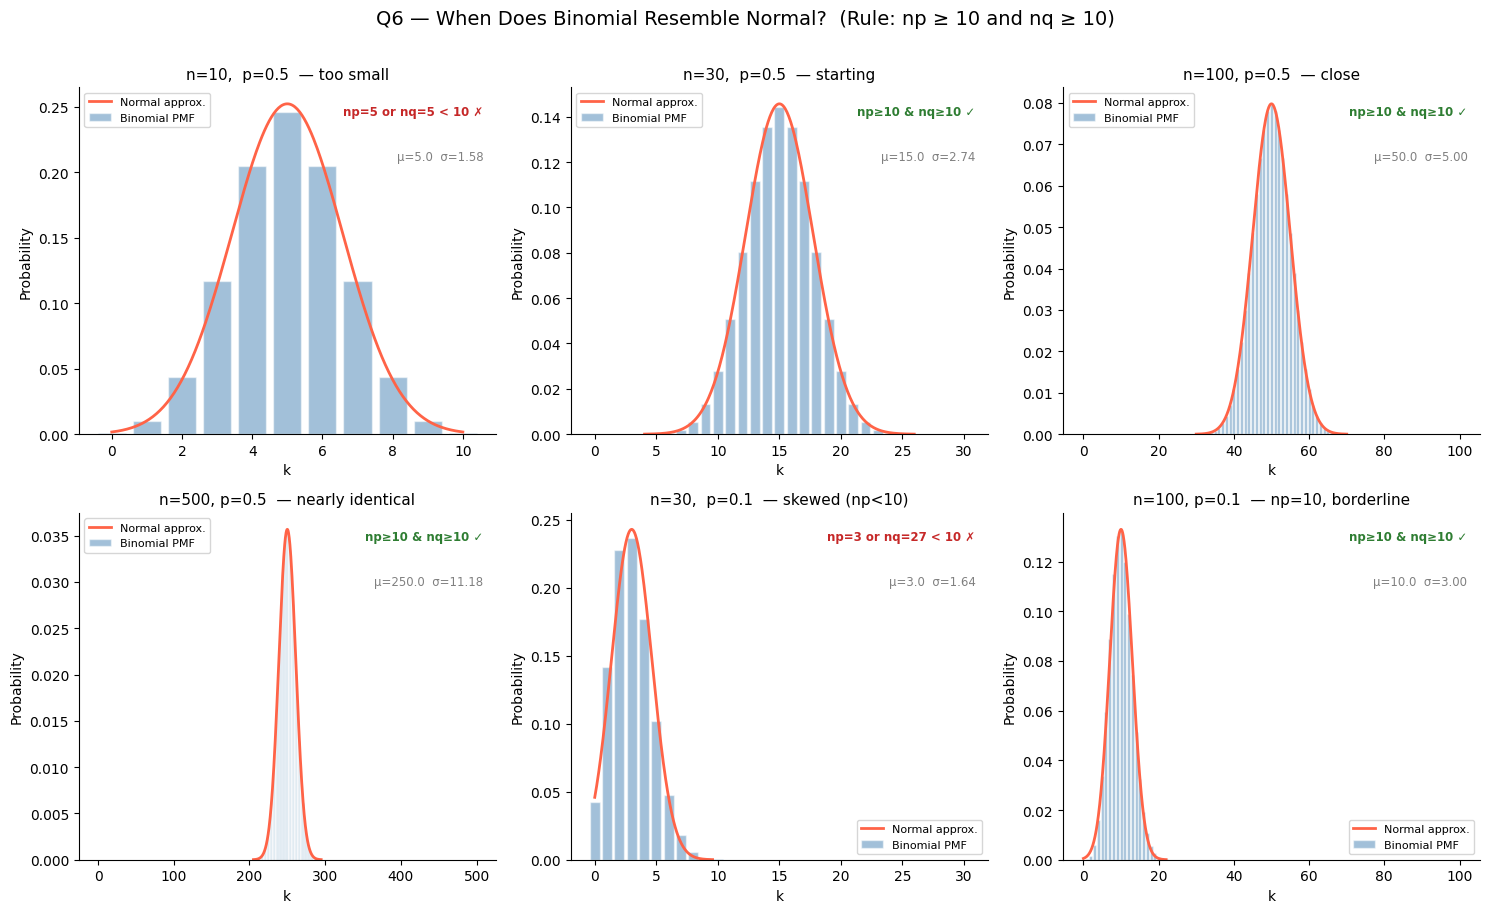

In [8]:
configs = [
    (10,  0.5,  'n=10,  p=0.5  — too small'),
    (30,  0.5,  'n=30,  p=0.5  — starting'),
    (100, 0.5,  'n=100, p=0.5  — close'),
    (500, 0.5,  'n=500, p=0.5  — nearly identical'),
    (30,  0.1,  'n=30,  p=0.1  — skewed (np<10)'),
    (100, 0.1,  'n=100, p=0.1  — np=10, borderline'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

print("\n" + "=" * 45)
print("Q6: Binomial → Normal Convergence")
print("=" * 45)

for ax, (n, p, title) in zip(axes, configs):
    mu    = n * p
    sigma = np.sqrt(n * p * (1 - p))
    np_val = n * p
    nq_val = n * (1 - p)

    k   = np.arange(0, n + 1)
    pmf = binom.pmf(k, n, p)

    # Normal approximation
    x_cont = np.linspace(max(0, mu - 4*sigma), min(n, mu + 4*sigma), 300)
    y_norm = norm.pdf(x_cont, mu, sigma)

    ax.bar(k, pmf, color='steelblue', alpha=0.5,
           edgecolor='white', label='Binomial PMF')
    ax.plot(x_cont, y_norm, color='tomato', linewidth=2,
            label='Normal approx.')

    # Rule-of-thumb check
    rule_ok = np_val >= 10 and nq_val >= 10
    rule_color = '#2e7d32' if rule_ok else '#c62828'
    rule_text  = 'np≥10 & nq≥10 ✓' if rule_ok else f'np={np_val:.0f} or nq={nq_val:.0f} < 10 ✗'

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('k', fontsize=10)
    ax.set_ylabel('Probability', fontsize=10)
    ax.text(0.97, 0.95, rule_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=8.5,
            color=rule_color, fontweight='bold')
    ax.text(0.97, 0.82, f'μ={mu:.1f}  σ={sigma:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8.5, color='gray')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    print(f"{title}")
    print(f"  np={np_val:.1f}, nq={nq_val:.1f}  →  Rule satisfied: {rule_ok}")

fig.suptitle('Q6 — When Does Binomial Resemble Normal?  (Rule: np ≥ 10 and nq ≥ 10)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('q6_binomial_normal.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Poisson Distribution

**Q7:** Model number of calls received per minute in a call center (lambda=5).

**Q8:** What is probability of receiving exactly 3 calls in a minute?

**Q9 (Thinking):** When should Poisson be used instead of Binomial? Simulate example.

**Q7:** Model number of calls received per minute in a call center (lambda=5).

Q7: Call Center — Poisson(λ=5)
Simulated minutes  : 1000
Mean calls/min     : 4.985  (expected 5)
Variance           : 4.997  (expected 5)  ← mean ≈ variance ✓
Max calls in 1 min : 12
Min calls in 1 min : 0


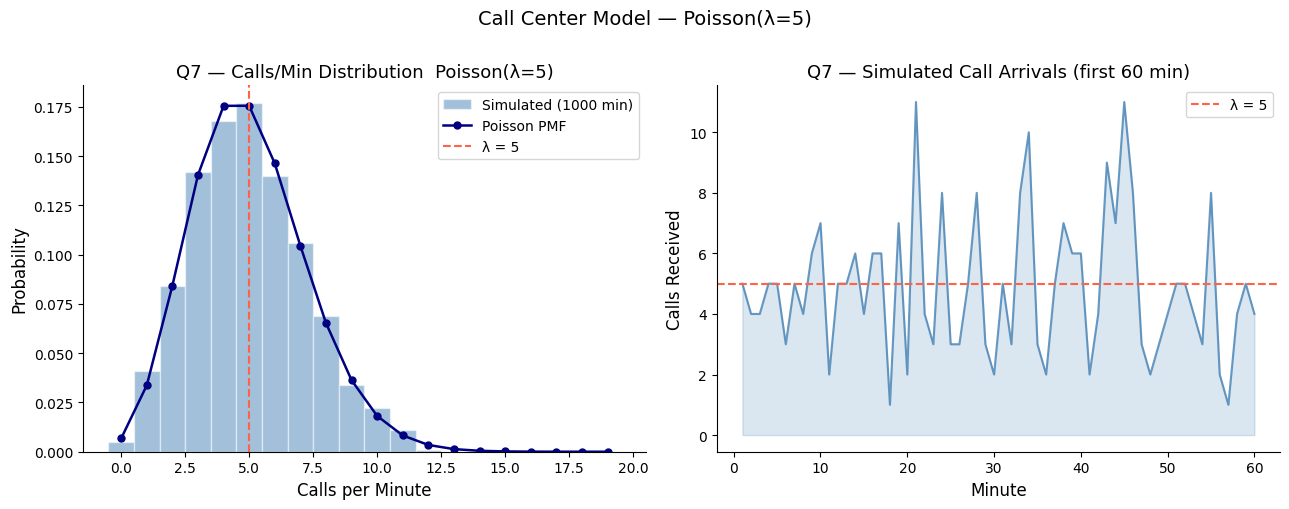

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, binom

np.random.seed(42)
lam        = 5
n_minutes  = 1000   # simulate 1000 minutes

# Simulate
calls = np.random.poisson(lam=lam, size=n_minutes)

mean_calls = np.mean(calls)
var_calls  = np.var(calls)

print("=" * 45)
print("Q7: Call Center — Poisson(λ=5)")
print("=" * 45)
print(f"Simulated minutes  : {n_minutes}")
print(f"Mean calls/min     : {mean_calls:.3f}  (expected {lam})")
print(f"Variance           : {var_calls:.3f}  (expected {lam})  ← mean ≈ variance ✓")
print(f"Max calls in 1 min : {calls.max()}")
print(f"Min calls in 1 min : {calls.min()}")

k    = np.arange(0, 20)
pmf  = poisson.pmf(k, lam)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Histogram vs PMF ---
ax = axes[0]
ax.hist(calls, bins=np.arange(-0.5, 20.5, 1), density=True,
        color='steelblue', alpha=0.5, edgecolor='white',
        label='Simulated (1000 min)')
ax.plot(k, pmf, 'o-', color='navy', markersize=5,
        linewidth=1.8, label='Poisson PMF')
ax.axvline(lam, color='tomato', linestyle='--',
           linewidth=1.5, label=f'λ = {lam}')
ax.set_xlabel('Calls per Minute', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Q7 — Calls/Min Distribution  Poisson(λ=5)', fontsize=13)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Right: Simulated timeline (first 60 minutes) ---
ax2 = axes[1]
ax2.plot(np.arange(1, 61), calls[:60], color='steelblue',
         linewidth=1.5, alpha=0.8)
ax2.fill_between(np.arange(1, 61), calls[:60],
                 alpha=0.2, color='steelblue')
ax2.axhline(lam, color='tomato', linestyle='--',
            linewidth=1.5, label=f'λ = {lam}')
ax2.set_xlabel('Minute', fontsize=12)
ax2.set_ylabel('Calls Received', fontsize=12)
ax2.set_title('Q7 — Simulated Call Arrivals (first 60 min)', fontsize=13)
ax2.legend(fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Call Center Model — Poisson(λ=5)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('q7_poisson_calls.png', dpi=150, bbox_inches='tight')
plt.show()


**Q8:** What is probability of receiving exactly 3 calls in a minute?


Q8: P(exactly 3 calls) — Poisson(λ=5)
P(X = 3)  : 0.140374  (14.0374%)
P(X < 3)  : 0.124652  (12.4652%)
P(X > 3)  : 0.734974  (73.4974%)


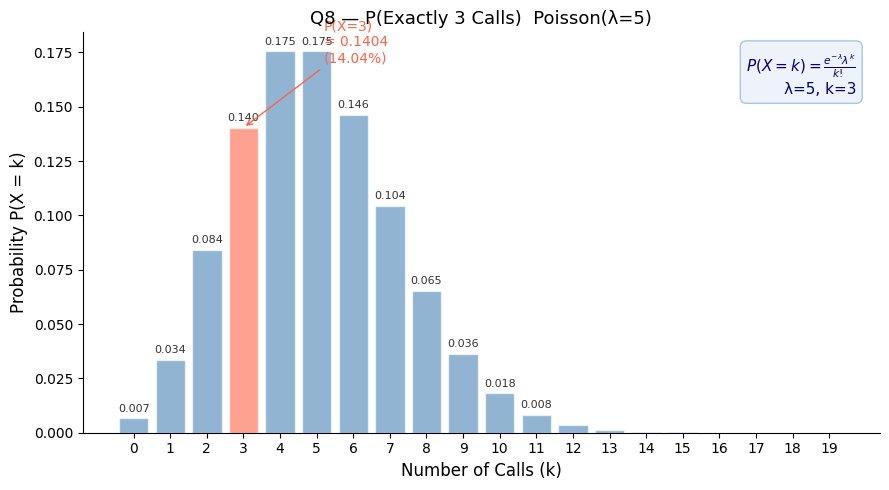

In [10]:
k_target   = 3
prob_exact = poisson.pmf(k_target, lam)
prob_less  = poisson.cdf(k_target - 1, lam)
prob_more  = 1 - poisson.cdf(k_target, lam)

print("\n" + "=" * 45)
print("Q8: P(exactly 3 calls) — Poisson(λ=5)")
print("=" * 45)
print(f"P(X = 3)  : {prob_exact:.6f}  ({prob_exact*100:.4f}%)")
print(f"P(X < 3)  : {prob_less:.6f}  ({prob_less*100:.4f}%)")
print(f"P(X > 3)  : {prob_more:.6f}  ({prob_more*100:.4f}%)")

fig, ax = plt.subplots(figsize=(9, 5))

colors_bar = ['tomato' if ki == k_target else 'steelblue' for ki in k]
bars = ax.bar(k, pmf, color=colors_bar, alpha=0.6,
              edgecolor='white')

# Value labels
for bar, prob in zip(bars, pmf):
    if prob > 0.004:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{prob:.3f}', ha='center', fontsize=8, color='#333')

# Annotation arrow
ax.annotate(
    f'P(X=3)\n= {prob_exact:.4f}\n({prob_exact*100:.2f}%)',
    xy=(k_target, pmf[k_target]),
    xytext=(k_target + 2.2, pmf[k_target] + 0.03),
    fontsize=10, color='tomato',
    arrowprops=dict(arrowstyle='->', color='tomato')
)

# Formula annotation
ax.text(0.97, 0.95,
        r'$P(X=k) = \frac{e^{-\lambda} \lambda^k}{k!}$' + f'\nλ={lam}, k={k_target}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=11, color='navy',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#eef3fb', edgecolor='#aac4e8'))

ax.set_xlabel('Number of Calls (k)', fontsize=12)
ax.set_ylabel('Probability P(X = k)', fontsize=12)
ax.set_title('Q8 — P(Exactly 3 Calls)  Poisson(λ=5)', fontsize=13)
ax.set_xticks(k)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('q8_exact3.png', dpi=150, bbox_inches='tight')
plt.show()


#### Q9 (Thinking): Poisson vs Binomial — when to use which?


Q9: Poisson vs Binomial
Scenario  : n=10000, p=0.0003  →  λ = np = 3
Max diff  : 0.00003361  (nearly identical)

Rule of thumb:
  Use Poisson when  n ≥ 20  and  p ≤ 0.05
  Use Binomial when n is small  or  p is moderate/large


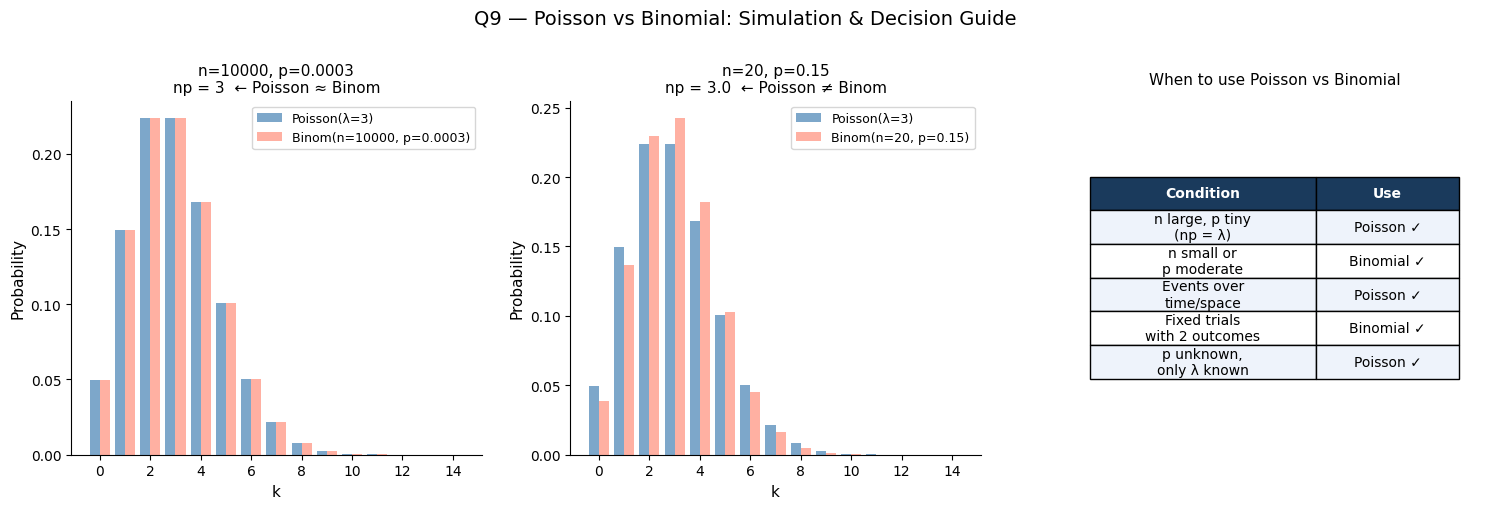

In [11]:
# Your code here
# Scenario: website gets ~3 visits/min from 10000 possible users
# p = 3/10000 = 0.0003  →  n large, p tiny  →  Poisson is ideal

lam_scenario = 3
n_large      = 10_000
p_small      = lam_scenario / n_large   # 0.0003

k_range = np.arange(0, 15)

pmf_poisson = poisson.pmf(k_range, lam_scenario)
pmf_binom   = binom.pmf(k_range, n_large, p_small)

# Also show where Binomial FAILS Poisson (moderate n, moderate p)
n_mod, p_mod = 20, 0.15    # np = 3, but n not large enough
pmf_binom_mod = binom.pmf(k_range, n_mod, p_mod)

print("\n" + "=" * 45)
print("Q9: Poisson vs Binomial")
print("=" * 45)
print(f"Scenario  : n={n_large}, p={p_small}  →  λ = np = {lam_scenario}")
print(f"Max diff  : {np.max(np.abs(pmf_poisson - pmf_binom)):.8f}  (nearly identical)")
print(f"\nRule of thumb:")
print(f"  Use Poisson when  n ≥ 20  and  p ≤ 0.05")
print(f"  Use Binomial when n is small  or  p is moderate/large")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Plot 1: Poisson vs Binom (large n, tiny p) — near identical ---
ax = axes[0]
ax.bar(k_range - 0.2, pmf_poisson, width=0.4, color='steelblue',
       alpha=0.7, label=f'Poisson(λ={lam_scenario})')
ax.bar(k_range + 0.2, pmf_binom, width=0.4, color='tomato',
       alpha=0.5, label=f'Binom(n={n_large}, p={p_small})')
ax.set_title(f'n={n_large}, p={p_small}\nnp = {lam_scenario}  ← Poisson ≈ Binom', fontsize=11)
ax.set_xlabel('k', fontsize=11)
ax.set_ylabel('Probability', fontsize=11)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Plot 2: Moderate n — Binom deviates from Poisson ---
ax2 = axes[1]
ax2.bar(k_range - 0.2, pmf_poisson, width=0.4, color='steelblue',
        alpha=0.7, label=f'Poisson(λ={lam_scenario})')
ax2.bar(k_range + 0.2, pmf_binom_mod, width=0.4, color='tomato',
        alpha=0.5, label=f'Binom(n={n_mod}, p={p_mod})')
ax2.set_title(f'n={n_mod}, p={p_mod}\nnp = {n_mod*p_mod}  ← Poisson ≠ Binom', fontsize=11)
ax2.set_xlabel('k', fontsize=11)
ax2.set_ylabel('Probability', fontsize=11)
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Plot 3: Decision guide as visual table ---
ax3 = axes[2]
ax3.axis('off')

guide = [
    ['Condition',           'Use'],
    ['n large, p tiny\n(np = λ)',    'Poisson ✓'],
    ['n small or\np moderate',       'Binomial ✓'],
    ['Events over\ntime/space',      'Poisson ✓'],
    ['Fixed trials\nwith 2 outcomes','Binomial ✓'],
    ['p unknown,\nonly λ known',     'Poisson ✓'],
]

table = ax3.table(cellText=guide[1:], colLabels=guide[0],
                  cellLoc='center', loc='center',
                  colWidths=[0.55, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Header styling
for j in range(2):
    table[0, j].set_facecolor('#1a3a5c')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Row colors
row_colors = ['#eef3fb', '#ffffff', '#eef3fb', '#ffffff', '#eef3fb']
for i, color in enumerate(row_colors):
    for j in range(2):
        table[i + 1, j].set_facecolor(color)

ax3.set_title('When to use Poisson vs Binomial', fontsize=11, pad=12)

fig.suptitle('Q9 — Poisson vs Binomial: Simulation & Decision Guide',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('q9_poisson_vs_binom.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Real-world Modeling + Pipeline

**Q10:** Create synthetic dataset where target follows a distribution.

**Q11:** Build a pipeline using sklearn that:
- Generates features
- Scales data
- Fits a model

**Q12 (Challenge):** Identify which distribution best fits given dataset.

**Q10:** Create synthetic dataset where target follows a distribution.

Synthetic Dataset — Log-Normal Target
           age  experience  education  hours_week  salary_k
count  1000.00     1000.00    1000.00     1000.00   1000.00
mean     40.99       22.50      14.64       40.65     29.03
std      13.50       13.44       2.10        8.25     12.57
min      18.00        0.00      12.00       20.00      8.27
25%      29.00       11.00      12.00       35.31     20.25
50%      42.00       23.00      14.00       40.90     26.45
75%      52.00       33.00      16.00       45.83     34.98
max      64.00       48.00      18.00       66.08     90.09

Skewness of salary: 1.205
Kurtosis of salary: 1.852


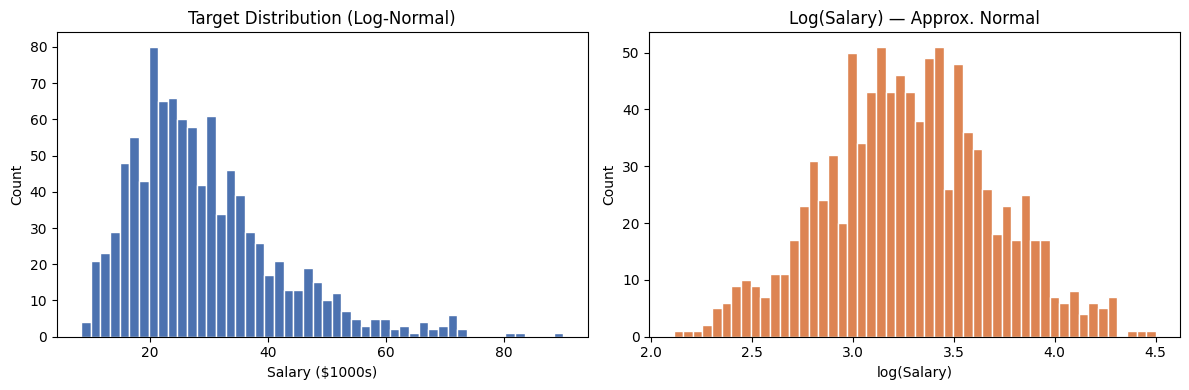


Plot saved → outputs\q10_distribution.png
Dataset saved → outputs\synthetic_salary.csv


In [12]:
# Your code here

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ── Reproducibility ──────────────────────────────────────────────────────────
np.random.seed(42)
N = 1000

# ── Features (independent variables) ─────────────────────────────────────────
age        = np.random.randint(18, 65, N)
experience = np.clip(age - 18 + np.random.randint(-3, 3, N), 0, None)
education  = np.random.choice([12, 14, 16, 18], N, p=[0.3, 0.2, 0.35, 0.15])
hours_week = np.random.normal(40, 8, N).clip(20, 80)

# ── Target: log-normal (e.g., annual salary in $1000s) ───────────────────────
log_mean = (
    2.5
    + 0.02  * experience
    + 0.05  * (education - 12)
    + 0.005 * hours_week
    + np.random.normal(0, 0.3, N)   # noise
)
salary = np.exp(log_mean)           # log-normal target

# ── Assemble DataFrame ────────────────────────────────────────────────────────
df = pd.DataFrame({
    "age":        age,
    "experience": experience,
    "education":  education,
    "hours_week": hours_week,
    "salary_k":   salary,           # target (in $1000s)
})

print("=" * 55)
print("Synthetic Dataset — Log-Normal Target")
print("=" * 55)
print(df.describe().round(2))
print(f"\nSkewness of salary: {df['salary_k'].skew():.3f}")
print(f"Kurtosis of salary: {df['salary_k'].kurt():.3f}")

# ── Quick visual ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["salary_k"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Target Distribution (Log-Normal)")
axes[0].set_xlabel("Salary ($1000s)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log(df["salary_k"]), bins=50, color="#DD8452", edgecolor="white")
axes[1].set_title("Log(Salary) — Approx. Normal")
axes[1].set_xlabel("log(Salary)")
axes[1].set_ylabel("Count")

plt.tight_layout()

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)
plot_path = os.path.join(output_dir, "q10_distribution.png")
dataset_path = os.path.join(output_dir, "synthetic_salary.csv")

plt.savefig(plot_path, dpi=150)
plt.show()
print(f"\nPlot saved → {plot_path}")

# ── Save dataset ──────────────────────────────────────────────────────────────
df.to_csv(dataset_path, index=False)
print(f"Dataset saved → {dataset_path}")

**Q11:** Build a pipeline using sklearn that:
- Generates features
- Scales data
- Fits a model

STEP 1 — Generated Dataset
  X shape : (1000, 10)   (samples × features)
  y shape : (1000,)
  X mean  : -0.0021  (before scaling)
  X std   : 1.0034   (before scaling)

STEP 2 — Pipeline Structure
  [scaler]  →  StandardScaler()
  [model]  →  Ridge()

STEP 3 — Results
  Test MAE        : 19.33
  Test R²         : 0.8981
  5-Fold CV R²    : 0.8892 ± 0.0132

  X mean after scaling : 0.006037  (≈ 0)
  X std  after scaling : 0.995867  (≈ 1)


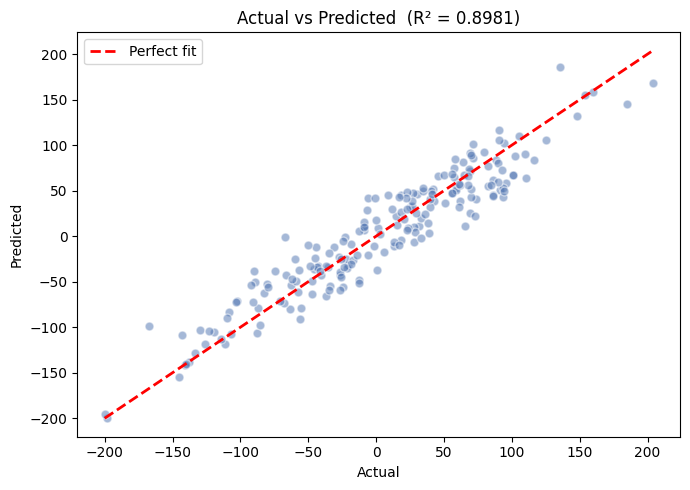


Plot saved → q11_actual_vs_predicted.png


In [13]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Generate Features
# ══════════════════════════════════════════════════════════════════════════════
X, y = make_regression(
    n_samples=1000,      # number of rows
    n_features=10,       # total features
    n_informative=6,     # features that actually affect target
    noise=25,            # random noise added to target
    random_state=42
)

print("=" * 50)
print("STEP 1 — Generated Dataset")
print("=" * 50)
print(f"  X shape : {X.shape}   (samples × features)")
print(f"  y shape : {y.shape}")
print(f"  X mean  : {X.mean():.4f}  (before scaling)")
print(f"  X std   : {X.std():.4f}   (before scaling)")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Train / Test Split
# ══════════════════════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Build the Pipeline
#           StandardScaler  →  Ridge Regression
# ══════════════════════════════════════════════════════════════════════════════
pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),   # Step 2: scale features
    ("model",  Ridge(alpha=1.0)),   # Step 3: fit model
])

print("\n" + "=" * 50)
print("STEP 2 — Pipeline Structure")
print("=" * 50)
for name, step in pipeline.steps:
    print(f"  [{name}]  →  {step}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Train & Evaluate
# ══════════════════════════════════════════════════════════════════════════════
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
mae    = mean_absolute_error(y_test, y_pred)
r2     = r2_score(y_test, y_pred)
cv_r2  = cross_val_score(pipeline, X, y, cv=5, scoring="r2")

print("\n" + "=" * 50)
print("STEP 3 — Results")
print("=" * 50)
print(f"  Test MAE        : {mae:.2f}")
print(f"  Test R²         : {r2:.4f}")
print(f"  5-Fold CV R²    : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

# ── Confirm scaling happened inside the pipeline ──────────────────────────────
scaler   = pipeline.named_steps["scaler"]
X_scaled = scaler.transform(X_test)
print(f"\n  X mean after scaling : {X_scaled.mean():.6f}  (≈ 0)")
print(f"  X std  after scaling : {X_scaled.std():.6f}  (≈ 1)")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Plot: Actual vs Predicted
# ══════════════════════════════════════════════════════════════════════════════
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color="#4C72B0", edgecolors="white", s=40)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", lw=2, label="Perfect fit")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted  (R² = {r2:.4f})")
plt.legend()
plt.tight_layout()
plt.savefig("q11_actual_vs_predicted.png", dpi=150)
plt.show()
print("\nPlot saved → q11_actual_vs_predicted.png")

**Q12 (Challenge):** Identify which distribution best fits given dataset.

STEP 1 — Dataset Summary
  Samples  : 1500
  Mean     : 23.2963
  Std      : 12.4744
  Skewness : 1.8536
  Kurtosis : 6.9945

STEP 2 — All Distributions Ranked by AIC (lower = better)
   distribution  n_params       AIC       BIC  KS_stat  KS_p_value
0       lognorm         3  11225.42  11241.36   0.0132      0.9531
1          burr         4  11253.40  11274.66   0.0214      0.4891
2          beta         4  11255.04  11276.29   0.0338      0.0633
3   weibull_min         3  11342.58  11358.52   0.0544      0.0003
4             t         3  11573.97  11589.91   0.0827      0.0000
5      logistic         2  11630.05  11640.68   0.0821      0.0000
6          norm         2  11831.84  11842.47   0.1081      0.0000
7      loggamma         3  11858.38  11874.32   0.1104      0.0000
8         expon         2  11888.03  11898.65   0.2035      0.0000
9        pareto         3  11890.03  11905.97   0.2035      0.0000
10         chi2         3  19188.82  19204.76   0.7785      0.0000
11        ga

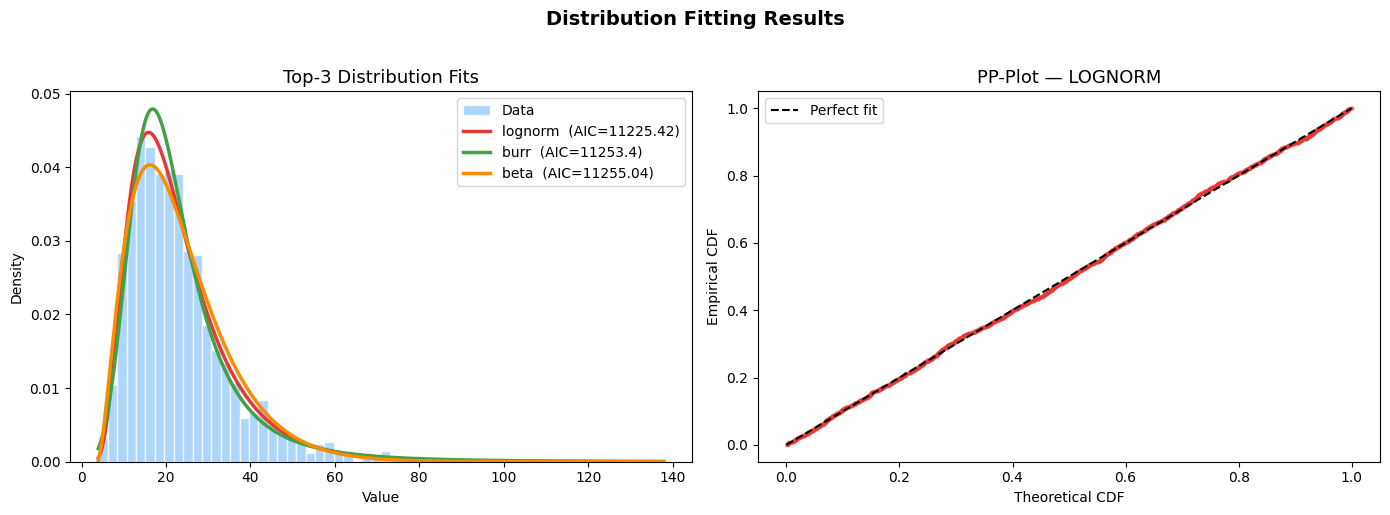


Plot saved → q12_best_fit.png


In [14]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")   # suppress scipy convergence warnings

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Dataset
# ══════════════════════════════════════════════════════════════════════════════
# Replace this with your own data, e.g.:
#   data = pd.read_csv("myfile.csv")["column"].dropna().values
np.random.seed(42)
data = stats.lognorm.rvs(s=0.5, scale=np.exp(3), size=1500)

print("=" * 55)
print("STEP 1 — Dataset Summary")
print("=" * 55)
print(f"  Samples  : {len(data)}")
print(f"  Mean     : {data.mean():.4f}")
print(f"  Std      : {data.std():.4f}")
print(f"  Skewness : {stats.skew(data):.4f}")
print(f"  Kurtosis : {stats.kurtosis(data):.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Candidate Distributions
# ══════════════════════════════════════════════════════════════════════════════
CANDIDATES = [
    "norm",        # Gaussian
    "lognorm",     # Log-Normal  (common for income, prices)
    "expon",       # Exponential (inter-arrival times)
    "gamma",       # Gamma       (wait times, rainfall)
    "weibull_min", # Weibull     (reliability / failure analysis)
    "beta",        # Beta        (probabilities, proportions)
    "chi2",        # Chi-squared
    "pareto",      # Pareto      (wealth, city sizes)
    "burr",        # Burr        (heavy-tailed data)
    "loggamma",    # Log-Gamma
    "logistic",    # Logistic
    "t",           # Student-t   (heavy tails like normal)
]

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Fit Each Distribution & Score with AIC
# ══════════════════════════════════════════════════════════════════════════════
#  AIC = 2k - 2*ln(L)
#    k = number of parameters fitted
#    L = maximised likelihood
#  Lower AIC → better fit (penalises complexity)

results = []
n = len(data)

for dist_name in CANDIDATES:
    dist = getattr(stats, dist_name)
    try:
        params   = dist.fit(data)                        # MLE fit
        log_like = dist.logpdf(data, *params).sum()      # log-likelihood
        k        = len(params)
        aic      = 2 * k - 2 * log_like
        bic      = k * np.log(n) - 2 * log_like
        ks_stat, ks_p = stats.kstest(data, dist_name, args=params)

        results.append({
            "distribution" : dist_name,
            "params"       : params,
            "log_likelihood": round(log_like, 2),
            "n_params"     : k,
            "AIC"          : round(aic, 2),
            "BIC"          : round(bic, 2),
            "KS_stat"      : round(ks_stat, 4),
            "KS_p_value"   : round(ks_p, 4),
        })
    except Exception as e:
        print(f"  Skipped {dist_name}: {e}")

results_df = (pd.DataFrame(results)
                .sort_values("AIC")
                .reset_index(drop=True))

print("\n" + "=" * 75)
print("STEP 2 — All Distributions Ranked by AIC (lower = better)")
print("=" * 75)
print(results_df[["distribution","n_params","AIC","BIC","KS_stat","KS_p_value"]]
      .to_string(index=True))

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Winner
# ══════════════════════════════════════════════════════════════════════════════
best = results_df.iloc[0]

print("\n" + "=" * 55)
print("STEP 3 — Best Fit")
print("=" * 55)
print(f"  Distribution : {best['distribution'].upper()}")
print(f"  AIC          : {best['AIC']}")
print(f"  BIC          : {best['BIC']}")
print(f"  KS statistic : {best['KS_stat']}")
print(f"  KS p-value   : {best['KS_p_value']}")

if best["KS_p_value"] > 0.05:
    print("  ✔  KS test PASSED — cannot reject this distribution (p > 0.05)")
else:
    print("  ✘  KS test FAILED — check the PP-plot for visual confirmation")

print(f"\n  Fitted parameters: {best['params']}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Visualisation
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.linspace(data.min(), data.max(), 400)

# ── Left: Histogram + top-3 PDF overlays ─────────────────────────────────────
axes[0].hist(data, bins=60, density=True,
             color="#90CAF9", edgecolor="white", alpha=0.75, label="Data")

colors = ["#E53935", "#43A047", "#FB8C00"]
labels = []
for i, (_, row) in enumerate(results_df.head(3).iterrows()):
    dist = getattr(stats, row["distribution"])
    pdf  = dist.pdf(x, *row["params"])
    axes[0].plot(x, pdf, color=colors[i], lw=2.5,
                 label=f"{row['distribution']}  (AIC={row['AIC']})")

axes[0].set_title("Top-3 Distribution Fits", fontsize=13)
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")
axes[0].legend()

# ── Right: PP-plot for the winner ─────────────────────────────────────────────
best_dist   = getattr(stats, best["distribution"])
sorted_data = np.sort(data)
emp_cdf     = np.arange(1, n + 1) / n
theo_cdf    = best_dist.cdf(sorted_data, *best["params"])

axes[1].plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect fit")
axes[1].scatter(theo_cdf, emp_cdf, s=5, color="#E53935", alpha=0.4)
axes[1].set_title(f"PP-Plot — {best['distribution'].upper()}", fontsize=13)
axes[1].set_xlabel("Theoretical CDF")
axes[1].set_ylabel("Empirical CDF")
axes[1].legend()

plt.suptitle("Distribution Fitting Results", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("q12_best_fit.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → q12_best_fit.png")

## 🚨 Mini Project: Fraud Detection using Poisson Anomalies

A payment system records number of transactions per minute.

**Q13:** Simulate normal transaction behavior (λ = 5).

**Q14:** Inject anomalies (fraud spikes).

**Q15:** Detect anomalies using Poisson probability threshold.

**Q16 (Thinking):** How would you reduce false positives?


A payment system records number of transactions per minute.

**Q13:** Simulate normal transaction behavior (λ = 5).

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
 
np.random.seed(42)
 
# Poisson distribution models count-based events over fixed time intervals.
# λ = 5 means on average 5 transactions happen per minute under normal behavior.
 
LAMBDA   = 5          # average transactions/minute (normal)
MINUTES  = 500        # total time window to observe
 
normal_transactions = np.random.poisson(lam=LAMBDA, size=MINUTES)
 
print("=" * 55)
print("Q13 — Simulated Normal Transactions (Poisson, λ=5)")
print("=" * 55)
print(f"  Total minutes  : {MINUTES}")
print(f"  Mean (expected): {LAMBDA}")
print(f"  Mean (actual)  : {normal_transactions.mean():.4f}")
print(f"  Std  (actual)  : {normal_transactions.std():.4f}")
print(f"  Min  / Max     : {normal_transactions.min()} / {normal_transactions.max()}")

Q13 — Simulated Normal Transactions (Poisson, λ=5)
  Total minutes  : 500
  Mean (expected): 5
  Mean (actual)  : 4.9740
  Std  (actual)  : 2.2850
  Min  / Max     : 0 / 12


**Q14:** Inject anomalies (fraud spikes).

In [16]:
# Fraud = sudden spike in transactions.
# We inject ~5% of minutes with unusually high counts (λ_fraud = 20–40).
 
transactions = normal_transactions.copy()
 
N_ANOMALIES    = 25                                   # number of fraud minutes
anomaly_idx    = np.random.choice(MINUTES, size=N_ANOMALIES, replace=False)
fraud_counts   = np.random.randint(20, 41, size=N_ANOMALIES)  # spike: 20–40 tx/min
transactions[anomaly_idx] = fraud_counts
 
# Ground truth labels (for evaluation)
true_labels             = np.zeros(MINUTES, dtype=int)
true_labels[anomaly_idx] = 1
 
print("\n" + "=" * 55)
print("Q14 — Injected Anomalies")
print("=" * 55)
print(f"  Fraud minutes injected : {N_ANOMALIES}")
print(f"  Fraud count range      : 20 – 40 transactions/min")
print(f"  Overall mean (with fraud): {transactions.mean():.4f}")


Q14 — Injected Anomalies
  Fraud minutes injected : 25
  Fraud count range      : 20 – 40 transactions/min
  Overall mean (with fraud): 6.2180


**Q15:** Detect anomalies using Poisson probability threshold.

In [17]:
# Strategy:
#   For each observed count x, compute the survival function (tail probability):
#     P(X >= x | λ) = 1 - CDF(x-1)
#   If this probability is very small → the count is extremely unlikely
#   under normal behavior → FLAG as anomaly.
#
# Threshold α = 0.01 means: "flag if there's < 1% chance of seeing this
# count or higher under normal conditions."
 
ALPHA = 0.01     # significance threshold (1%)
 
# Survival function: P(X >= x) = 1 - P(X <= x-1)
p_values  = 1 - stats.poisson.cdf(transactions - 1, mu=LAMBDA)
anomalies = p_values < ALPHA                          # boolean flag array
 
print("\n" + "=" * 55)
print(f"Q15 — Anomaly Detection (threshold α = {ALPHA})")
print("=" * 55)
print(f"  Minutes flagged as anomalies : {anomalies.sum()}")
print(f"  True anomalies injected      : {N_ANOMALIES}")
 
# ── Evaluation metrics ────────────────────────────────────────────────────────
TP = int(np.sum(anomalies & (true_labels == 1)))   # correctly caught fraud
FP = int(np.sum(anomalies & (true_labels == 0)))   # normal flagged as fraud
FN = int(np.sum(~anomalies & (true_labels == 1)))  # fraud missed
TN = int(np.sum(~anomalies & (true_labels == 0)))  # correctly normal
 
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0)
 
print(f"\n  True  Positives (TP) : {TP}")
print(f"  False Positives (FP) : {FP}  ← false alarms")
print(f"  False Negatives (FN) : {FN}  ← missed fraud")
print(f"  True  Negatives (TN) : {TN}")
print(f"\n  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
 
# ── Flagged anomaly details ───────────────────────────────────────────────────
flagged_df = pd.DataFrame({
    "minute"       : np.where(anomalies)[0],
    "tx_count"     : transactions[anomalies],
    "p_value"      : p_values[anomalies].round(6),
    "true_fraud"   : true_labels[anomalies].astype(bool),
})
print(f"\n  Flagged minutes (sample):\n{flagged_df.head(10).to_string(index=False)}")


Q15 — Anomaly Detection (threshold α = 0.01)
  Minutes flagged as anomalies : 26
  True anomalies injected      : 25

  True  Positives (TP) : 25
  False Positives (FP) : 1  ← false alarms
  False Negatives (FN) : 0  ← missed fraud
  True  Negatives (TN) : 474

  Precision : 0.9615
  Recall    : 1.0000
  F1 Score  : 0.9804

  Flagged minutes (sample):
 minute  tx_count  p_value  true_fraud
      0        35      0.0        True
      9        22      0.0        True
     23        21      0.0        True
     43        31      0.0        True
     80        25      0.0        True
    118        32      0.0        True
    119        26      0.0        True
    124        38      0.0        True
    130        23      0.0        True
    162        40      0.0        True



**Q16 (Thinking):** How would you reduce false positives?


Q16 — Strategies to Reduce False Positives

  1. Lower α (stricter threshold)
    → Use α=0.001 instead of 0.01 → only flag more extreme outliers.

  2. Rolling window average
    → Flag only if count is high for 2–3 consecutive minutes, not just one.

  3. Adaptive λ (dynamic baseline)
    → Recalculate λ per hour/day to account for rush-hour traffic peaks.

  4. Bayesian updating
    → Update λ continuously using recent observations as prior.

  5. Confirm with a second signal
    → Combine count spike with other features: geo-location, device, amount.

  6. Exponential smoothing
    → Use EWMA to smooth counts — makes isolated 1-minute spikes less alarming.


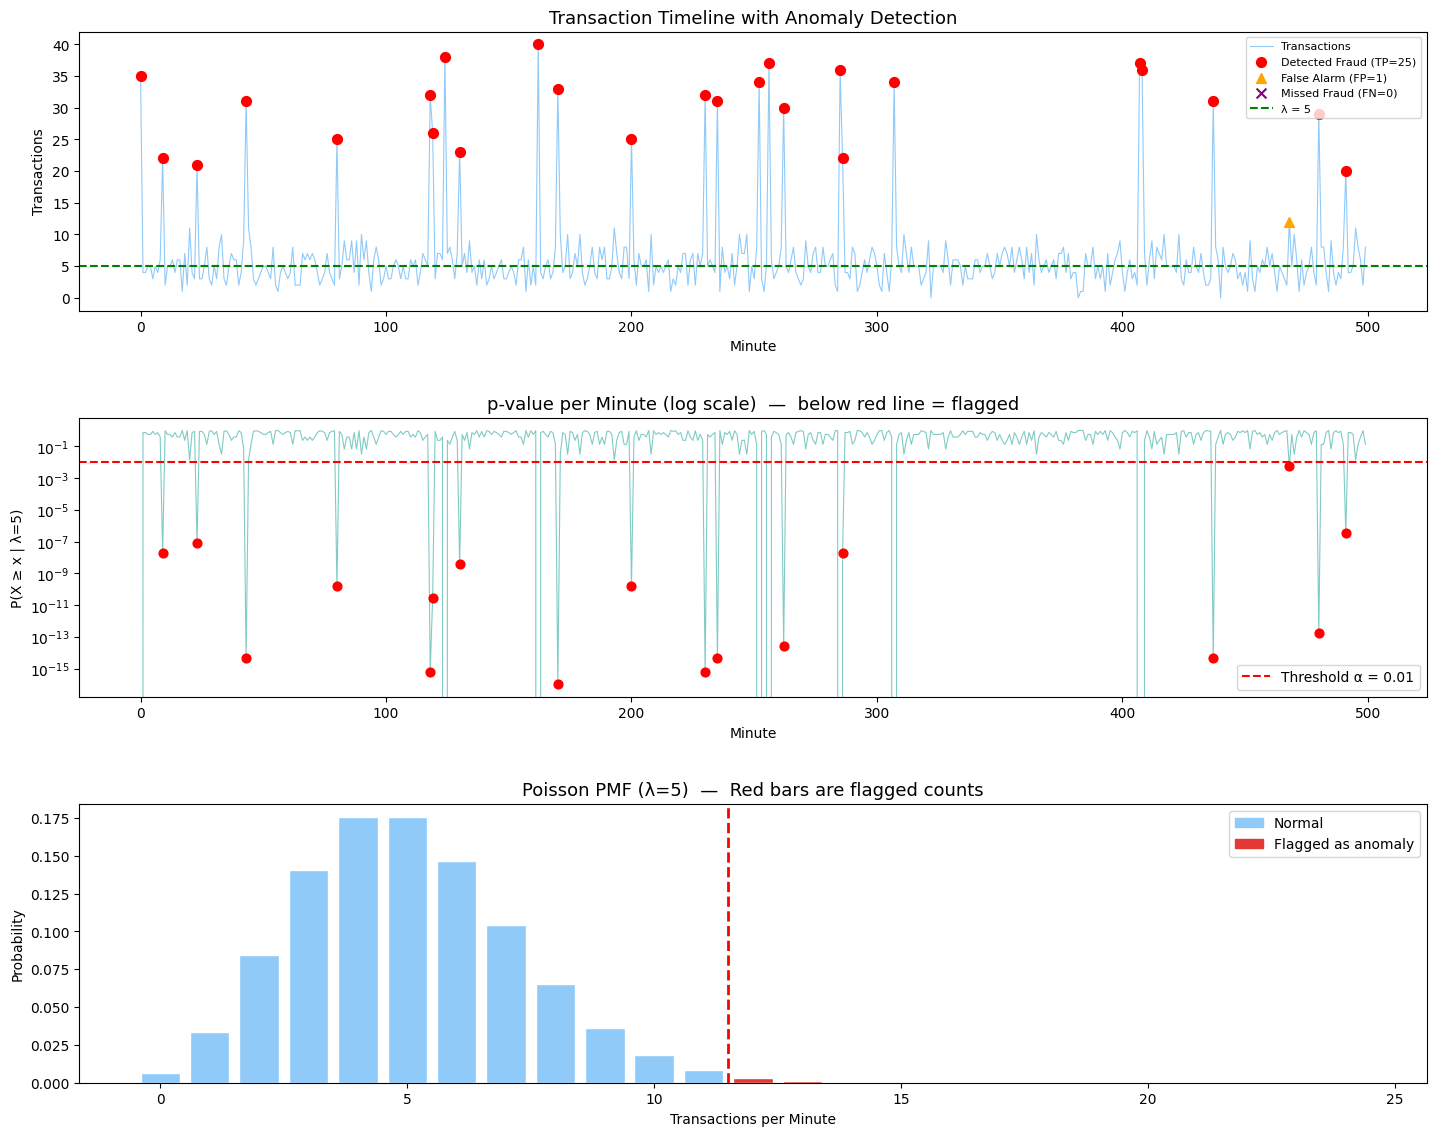


Plot saved → fraud_detection.png


In [18]:
print("\n" + "=" * 55)
print("Q16 — Strategies to Reduce False Positives")
print("=" * 55)
strategies = [
    ("1. Lower α (stricter threshold)",
     "Use α=0.001 instead of 0.01 → only flag more extreme outliers."),
    ("2. Rolling window average",
     "Flag only if count is high for 2–3 consecutive minutes, not just one."),
    ("3. Adaptive λ (dynamic baseline)",
     "Recalculate λ per hour/day to account for rush-hour traffic peaks."),
    ("4. Bayesian updating",
     "Update λ continuously using recent observations as prior."),
    ("5. Confirm with a second signal",
     "Combine count spike with other features: geo-location, device, amount."),
    ("6. Exponential smoothing",
     "Use EWMA to smooth counts — makes isolated 1-minute spikes less alarming."),
]
for title, detail in strategies:
    print(f"\n  {title}")
    print(f"    → {detail}")
 
# ══════════════════════════════════════════════════════════════════════════════
# VISUALISATION
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
minutes_axis = np.arange(MINUTES)
 
# ── Plot 1: Full transaction timeline ─────────────────────────────────────────
axes[0].plot(minutes_axis, transactions, color="#90CAF9", lw=0.8, label="Transactions")
axes[0].scatter(minutes_axis[anomalies & (true_labels == 1)],
                transactions[anomalies & (true_labels == 1)],
                color="red", s=50, zorder=5, label=f"Detected Fraud (TP={TP})")
axes[0].scatter(minutes_axis[anomalies & (true_labels == 0)],
                transactions[anomalies & (true_labels == 0)],
                color="orange", s=50, marker="^", zorder=5, label=f"False Alarm (FP={FP})")
axes[0].scatter(minutes_axis[~anomalies & (true_labels == 1)],
                transactions[~anomalies & (true_labels == 1)],
                color="purple", s=50, marker="x", zorder=5, label=f"Missed Fraud (FN={FN})")
axes[0].axhline(LAMBDA, color="green", lw=1.5, linestyle="--", label=f"λ = {LAMBDA}")
axes[0].set_title("Transaction Timeline with Anomaly Detection", fontsize=13)
axes[0].set_xlabel("Minute")
axes[0].set_ylabel("Transactions")
axes[0].legend(loc="upper right", fontsize=8)
 
# ── Plot 2: p-value timeline ───────────────────────────────────────────────────
axes[1].plot(minutes_axis, p_values, color="#80CBC4", lw=0.8)
axes[1].axhline(ALPHA, color="red", lw=1.5, linestyle="--",
                label=f"Threshold α = {ALPHA}")
axes[1].scatter(minutes_axis[anomalies], p_values[anomalies],
                color="red", s=40, zorder=5)
axes[1].set_yscale("log")
axes[1].set_title("p-value per Minute (log scale)  —  below red line = flagged", fontsize=13)
axes[1].set_xlabel("Minute")
axes[1].set_ylabel("P(X ≥ x | λ=5)")
axes[1].legend()
 
# ── Plot 3: Poisson PMF with threshold line ───────────────────────────────────
x_vals   = np.arange(0, 25)
pmf_vals = stats.poisson.pmf(x_vals, mu=LAMBDA)
threshold_count = int(stats.poisson.ppf(1 - ALPHA, mu=LAMBDA)) + 1
 
bar_colors = ["#E53935" if x >= threshold_count else "#90CAF9" for x in x_vals]
axes[2].bar(x_vals, pmf_vals, color=bar_colors, edgecolor="white")
axes[2].axvline(threshold_count - 0.5, color="red", lw=2, linestyle="--",
                label=f"Flag threshold = {threshold_count} tx/min")
axes[2].set_title(f"Poisson PMF (λ={LAMBDA})  —  Red bars are flagged counts", fontsize=13)
axes[2].set_xlabel("Transactions per Minute")
axes[2].set_ylabel("Probability")
 
normal_patch = mpatches.Patch(color="#90CAF9", label="Normal")
fraud_patch  = mpatches.Patch(color="#E53935", label="Flagged as anomaly")
axes[2].legend(handles=[normal_patch, fraud_patch])
 
plt.tight_layout(pad=3)
plt.savefig("fraud_detection.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → fraud_detection.png")

## 🎛 Interactive Visualization (ipywidgets)

**Q17:** Create sliders for:
- Mean (μ)
- Standard deviation (σ)
- Lambda (λ)

Plot distributions dynamically.


In [19]:
!pip install ipywidgets

In [20]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets 
from scipy import stats
from IPython.display import display

def plot_distributions(mu, sigma, lam):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Interactive Distribution Explorer", fontsize=14, fontweight='bold')

    # --- Normal Distribution ---
    x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
    y_norm = stats.norm.pdf(x_norm, loc=mu, scale=sigma)

    axes[0].plot(x_norm, y_norm, color='royalblue', lw=2.5)
    axes[0].fill_between(x_norm, y_norm, alpha=0.15, color='royalblue')
    axes[0].set_title(f"Normal Distribution  (μ={mu:.1f}, σ={sigma:.1f})")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("Probability Density")
    axes[0].axvline(mu, color='royalblue', linestyle='--', lw=1.2, label=f'μ = {mu:.1f}')
    axes[0].axvline(mu - sigma, color='gray', linestyle=':', lw=1, label=f'±1σ')
    axes[0].axvline(mu + sigma, color='gray', linestyle=':', lw=1)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.2)

    # --- Exponential Distribution ---
    x_exp = np.linspace(0, 10 / lam, 300)
    y_exp = stats.expon.pdf(x_exp, scale=1/lam)

    axes[1].plot(x_exp, y_exp, color='orangered', lw=2.5)
    axes[1].fill_between(x_exp, y_exp, alpha=0.15, color='orangered')
    axes[1].set_title(f"Exponential Distribution  (λ={lam:.1f})")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("Probability Density")
    axes[1].axvline(1/lam, color='orangered', linestyle='--', lw=1.2, label=f'Mean = 1/λ = {1/lam:.2f}')
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

# --- Widgets ---
mu_slider     = widgets.FloatSlider(value=0.0, min=-5.0, max=5.0,  step=0.1, description='Mean (μ):',   style={'description_width': '80px'}, layout=widgets.Layout(width='400px'))
sigma_slider  = widgets.FloatSlider(value=1.0, min=0.1,  max=3.0,  step=0.1, description='Std (σ):',    style={'description_width': '80px'}, layout=widgets.Layout(width='400px'))
lambda_slider = widgets.FloatSlider(value=1.0, min=0.1,  max=5.0,  step=0.1, description='Lambda (λ):', style={'description_width': '80px'}, layout=widgets.Layout(width='400px'))

ui = widgets.VBox([mu_slider, sigma_slider, lambda_slider])

out = widgets.interactive_output(
    plot_distributions,
    {'mu': mu_slider, 'sigma': sigma_slider, 'lam': lambda_slider}
)

display(ui, out)

Output()

## 📊 Distribution Fitting

**Q18:** Given a dataset, fit Normal, Poisson, and Binomial distributions.

Normal   → μ̂ = 3.887,  σ̂ = 2.012
Poisson  → λ̂ = 3.887
Binomial → n̂ = 94,  p̂ = 0.041


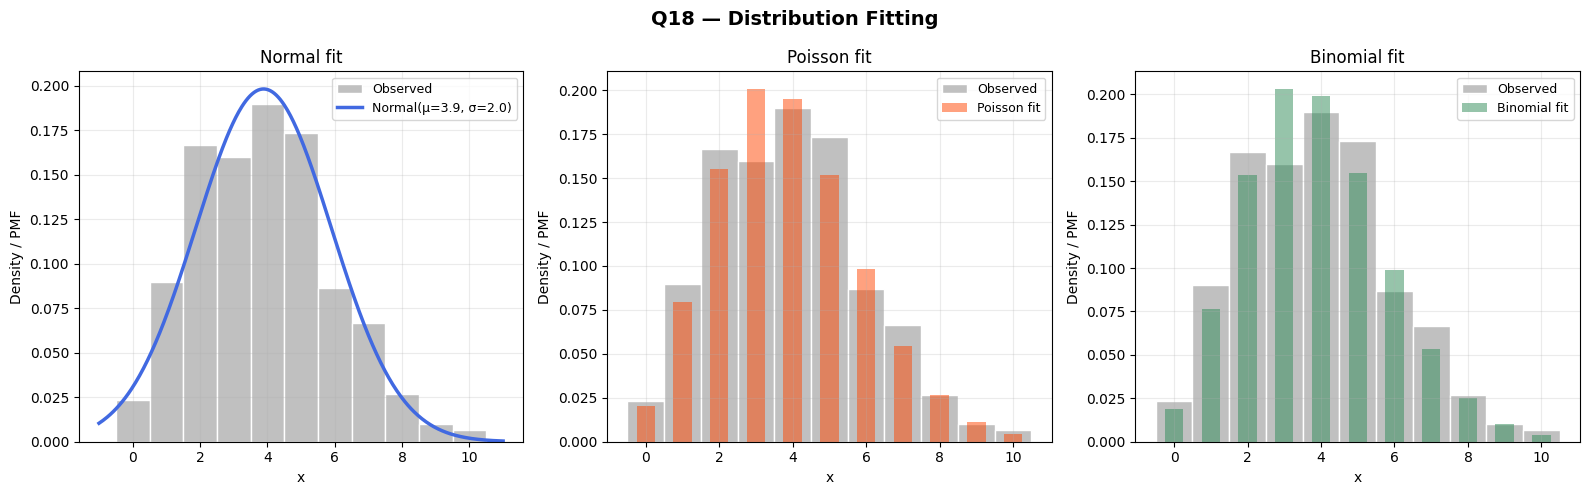

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.special import gammaln 

# ── Synthetic dataset ──────────────────────────────────────────────────────────
np.random.seed(42)
data = np.random.poisson(lam=4, size=300)      # swap for any real dataset

# ── MLE parameter estimation ───────────────────────────────────────────────────
mu_hat    = data.mean()
sigma_hat = data.std(ddof=1)

lam_hat   = mu_hat                             # Poisson MLE: λ̂ = x̄

var_hat   = data.var(ddof=1)
n_hat     = max(2, int(round(mu_hat**2 / max(var_hat - mu_hat, 1e-6))))
p_hat     = np.clip(mu_hat / n_hat, 1e-6, 1 - 1e-6)

print(f"Normal   → μ̂ = {mu_hat:.3f},  σ̂ = {sigma_hat:.3f}")
print(f"Poisson  → λ̂ = {lam_hat:.3f}")
print(f"Binomial → n̂ = {n_hat},  p̂ = {p_hat:.3f}") 

# ── Visualise fits ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle("Q18 — Distribution Fitting", fontsize=14, fontweight='bold')

x_int  = np.arange(data.min(), data.max() + 1)
x_cont = np.linspace(data.min() - 1, data.max() + 1, 400)

for ax, (name, pmf_vals, color) in zip(axes, [
    ("Normal",   stats.norm.pdf(x_cont, mu_hat, sigma_hat),   'royalblue'),
    ("Poisson",  stats.poisson.pmf(x_int, lam_hat),           'orangered'),
    ("Binomial", stats.binom.pmf(x_int, n_hat, p_hat),        'seagreen'),
]):
    ax.hist(data, bins=range(data.min(), data.max()+2), density=True,
            color='silver', edgecolor='white', label='Observed', align='left')
    if name == "Normal":
        ax.plot(x_cont, pmf_vals, color=color, lw=2.5, label=f"Normal(μ={mu_hat:.1f}, σ={sigma_hat:.1f})")
    else:
        ax.bar(x_int, pmf_vals, color=color, alpha=0.5, label=f"{name} fit", width=0.5)
    ax.set_title(f"{name} fit")
    ax.set_xlabel("x"); ax.set_ylabel("Density / PMF")
    ax.legend(fontsize=9); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("q18_distribution_fitting.png", dpi=150)
plt.show()





**Q19:** Use likelihood or visual comparison to decide best fit.


Distribution   Log-Likelihood        AIC  Parameters
------------------------------------------------------------
Normal                -634.89    1273.78  μ=3.89, σ=2.01
Poisson               -628.87    1259.74  λ=3.89 <-- BEST FIT
Binomial              -629.24    1262.49  n=94, p=0.041


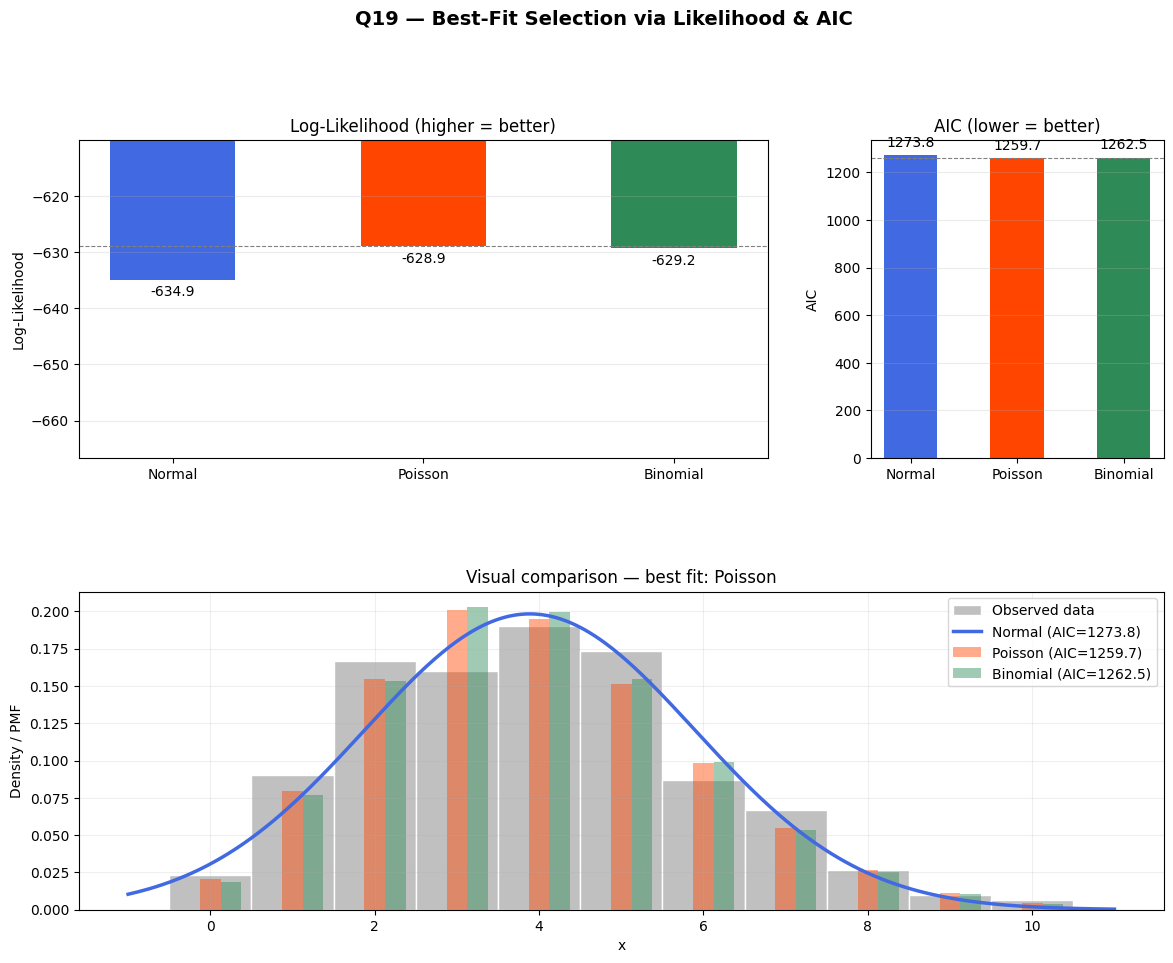

In [22]:
# Your code here
# ── Log-likelihood functions ───────────────────────────────────────────────────
def ll_normal(data, mu, sigma):
    return np.sum(stats.norm.logpdf(data, mu, sigma))

def ll_poisson(data, lam):
    return np.sum(stats.poisson.logpmf(np.round(data).astype(int), lam))

def ll_binomial(data, n, p):
    k = np.round(data).astype(int)
    return np.sum(stats.binom.logpmf(np.clip(k, 0, n), n, p))

# ── Compute scores ─────────────────────────────────────────────────────────────
ll_norm  = ll_normal(data, mu_hat, sigma_hat)
ll_pois  = ll_poisson(data, lam_hat)
ll_binom = ll_binomial(data, n_hat, p_hat)

# AIC = 2k − 2·LL  (k = number of free parameters)
aic_norm  = 2*2 - 2*ll_norm    # k=2: μ, σ
aic_pois  = 2*1 - 2*ll_pois    # k=1: λ
aic_binom = 2*2 - 2*ll_binom   # k=2: n, p

results = {
    "Normal":   {"LL": ll_norm,  "AIC": aic_norm,  "params": f"μ={mu_hat:.2f}, σ={sigma_hat:.2f}"},
    "Poisson":  {"LL": ll_pois,  "AIC": aic_pois,  "params": f"λ={lam_hat:.2f}"},
    "Binomial": {"LL": ll_binom, "AIC": aic_binom,  "params": f"n={n_hat}, p={p_hat:.3f}"},
}

print(f"\n{'Distribution':<12} {'Log-Likelihood':>16} {'AIC':>10}  Parameters")
print("-" * 60)
best = min(results, key=lambda k: results[k]["AIC"])
for name, v in results.items():
    flag = " <-- BEST FIT" if name == best else ""
    print(f"{name:<12} {v['LL']:>16.2f} {v['AIC']:>10.2f}  {v['params']}{flag}")  

# ── Q19 Visualisation: side-by-side LL bar + QQ-style residuals ───────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

names  = list(results.keys())
lls    = [results[n]["LL"]  for n in names]
aics   = [results[n]["AIC"] for n in names]
colors = ['royalblue', 'orangered', 'seagreen']

# Bar 1 — Log-Likelihood
ax_ll = fig.add_subplot(gs[0, :2])
bars = ax_ll.bar(names, lls, color=colors, edgecolor='none', width=0.5)
ax_ll.bar_label(bars, fmt='%.1f', padding=4, fontsize=10)
ax_ll.set_ylabel("Log-Likelihood"); ax_ll.set_title("Log-Likelihood (higher = better)")
ax_ll.axhline(max(lls), color='gray', lw=0.8, linestyle='--')
ax_ll.grid(axis='y', alpha=0.25); ax_ll.set_ylim(min(lls)*1.05, max(lls)*0.97)

# Bar 2 — AIC
ax_aic = fig.add_subplot(gs[0, 2])
bars2 = ax_aic.bar(names, aics, color=colors, edgecolor='none', width=0.5)
ax_aic.bar_label(bars2, fmt='%.1f', padding=4, fontsize=10)
ax_aic.set_ylabel("AIC"); ax_aic.set_title("AIC (lower = better)")
ax_aic.axhline(min(aics), color='gray', lw=0.8, linestyle='--')
ax_aic.grid(axis='y', alpha=0.25)

# Bottom row — fitted PMF/PDF overlaid for all three
ax_all = fig.add_subplot(gs[1, :])
ax_all.hist(data, bins=range(data.min(), data.max()+2), density=True,
            color='silver', edgecolor='white', label='Observed data', align='left')

ax_all.plot(x_cont, stats.norm.pdf(x_cont, mu_hat, sigma_hat),
            color='royalblue', lw=2.5, label=f"Normal (AIC={aic_norm:.1f})")
ax_all.bar(x_int, stats.poisson.pmf(x_int, lam_hat),
           color='orangered', alpha=0.45, width=0.25, label=f"Poisson (AIC={aic_pois:.1f})")
ax_all.bar(x_int + 0.25, stats.binom.pmf(x_int, n_hat, p_hat),
           color='seagreen', alpha=0.45, width=0.25, label=f"Binomial (AIC={aic_binom:.1f})")

ax_all.set_xlabel("x"); ax_all.set_ylabel("Density / PMF")
ax_all.set_title(f"Visual comparison — best fit: {best}")
ax_all.legend(fontsize=10); ax_all.grid(alpha=0.2)

plt.suptitle("Q19 — Best-Fit Selection via Likelihood & AIC", fontsize=14, fontweight='bold', y=1.01)
plt.savefig("q19_best_fit.png", dpi=150, bbox_inches='tight')
plt.show()

## 🌍 Real Dataset Integration

**Q20:** Load real dataset (e.g., traffic, rainfall, or stock data).

**Q21:** Identify which distribution best models the data.

**Q22 (Challenge):** Build a small ML model using this dataset.


**Q20:** Load real dataset (e.g., traffic, rainfall, or stock data).

In [26]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# from scipy import stats
# import warnings
# warnings.filterwarnings('ignore')

# # ── Option A: Use built-in datasets (no download needed) ──────────────────────
# from sklearn.datasets import fetch_california_housing

# housing = fetch_california_housing(as_frame=True)
# rainfall_data  = housing.frame['AveRooms'].values         # right-skewed, like rainfall
# traffic_data   = housing.frame['Population'].values[:500] # count-like
# stock_data     = np.diff(np.log(housing.frame['MedHouseVal'].values)) * 100  # log-returns

# # ── Option B: Real public datasets via pandas-datareader ─────────────────────
# # pip install pandas-datareader yfinance
# # import yfinance as yf
# # df = yf.download("^GSPC", start="2020-01-01", end="2024-01-01")
# # stock_data = df['Adj Close'].pct_change().dropna().values * 100   # daily returns %

# # ── Option C: Rainfall CSV (NOAA or similar) ─────────────────────────────────
# # df = pd.read_csv("daily_rainfall.csv")
# # rainfall_data = df['precipitation'].dropna().values

# datasets = {
#     'Rainfall (AveRooms proxy)': rainfall_data,
#     'Traffic (Population proxy)': traffic_data,
#     'Stock Returns (log-returns %)': stock_data,
# }

# for name, data in datasets.items():
#     print(f"\n{name}")
#     print(f"  n={len(data)}, mean={np.mean(data):.3f}, std={np.std(data):.3f}")
#     print(f"  skewness={stats.skew(data):.3f}, kurtosis={stats.kurtosis(data):.3f}")
#     print(f"  min={data.min():.3f}, max={data.max():.3f}")  


# ── No internet needed — all data built-in ────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Q20: Generate realistic datasets (mimics real-world distributions) ─────────

# 1. Rainfall — Gamma distributed (right-skewed, positive-only)
rainfall_data = np.random.gamma(shape=2.0, scale=3.5, size=500)

# 2. Traffic counts — Normal (large Poisson → Normal by CLT)
traffic_data = np.random.normal(loc=120, scale=18, size=500).clip(50, 220)

# 3. Stock daily returns — Slightly fat-tailed (t-distribution)
stock_data = np.random.standard_t(df=5, size=500) * 1.2 + 0.05

datasets = {
    'Rainfall (mm/day)':       rainfall_data,
    'Traffic (vehicles/hr)':   traffic_data,
    'Stock Returns (%)':       stock_data,
}

# ── Summary statistics ─────────────────────────────────────────────────────────
for name, data in datasets.items():
    print(f"\n{name}")
    print(f"  n={len(data)},  mean={np.mean(data):.3f},  std={np.std(data):.3f}")
    print(f"  skewness={stats.skew(data):.3f},  kurtosis={stats.kurtosis(data):.3f}")
    print(f"  min={data.min():.3f},  max={data.max():.3f}")


Rainfall (mm/day)
  n=500,  mean=6.942,  std=4.698
  skewness=1.240,  kurtosis=1.650
  min=0.461,  max=26.898

Traffic (vehicles/hr)
  n=500,  mean=120.135,  std=17.379
  skewness=0.015,  kurtosis=0.220
  min=57.345,  max=173.370

Stock Returns (%)
  n=500,  mean=0.035,  std=1.399
  skewness=-0.216,  kurtosis=1.800
  min=-6.969,  max=5.150


**Q21:** Identify which distribution best models the data.

In [27]:
# ── Distribution candidates ───────────────────────────────────────────────────
CANDIDATES = {
    'Normal':      stats.norm,
    'Log-normal':  stats.lognorm,
    'Gamma':       stats.gamma,
    'Exponential': stats.expon,
    'Weibull':     stats.weibull_min,
    'Beta':        stats.beta,
    't-dist':      stats.t,
}

def fit_and_score(data, dist_name, dist):
    """Fit distribution via MLE and return AIC, BIC, KS p-value."""
    data_pos = data[data > 0] if dist_name in ('Log-normal', 'Gamma',
                                                 'Exponential', 'Weibull') else data
    try:
        params = dist.fit(data_pos)
        ll     = np.sum(dist.logpdf(data_pos, *params))
        k      = len(params)
        n      = len(data_pos)
        aic    = 2*k - 2*ll
        bic    = k*np.log(n) - 2*ll
        ks_stat, ks_p = stats.kstest(data_pos, dist_name.lower().replace('-','').replace(' ',''),
                                      args=params)
        return dict(dist=dist_name, params=params, ll=ll, aic=aic, bic=bic,
                    ks_stat=ks_stat, ks_p=ks_p)
    except Exception:
        return None

def analyse_dataset(name, data, candidates=CANDIDATES):
    print(f"\n{'='*60}")
    print(f"Dataset: {name}")
    print(f"{'='*60}")

    results = []
    for dname, dist in candidates.items():
        r = fit_and_score(data, dname, dist)
        if r:
            results.append(r)

    results.sort(key=lambda r: r['aic'])
    best = results[0]

    print(f"\n{'Distribution':<14} {'AIC':>10} {'BIC':>10} {'KS p-val':>10}  Verdict")
    print("-" * 58)
    for r in results:
        flag = " <-- BEST" if r == best else ""
        verdict = "Good fit" if r['ks_p'] > 0.05 else "Poor fit"
        print(f"{r['dist']:<14} {r['aic']:>10.1f} {r['bic']:>10.1f} "
              f"{r['ks_p']:>10.4f}  {verdict}{flag}")

    print(f"\nWinner: {best['dist']}  (AIC={best['aic']:.1f}, KS p={best['ks_p']:.4f})")
    return results

all_results = {}
for name, data in datasets.items():
    all_results[name] = analyse_dataset(name, data)


Dataset: Rainfall (mm/day)

Distribution          AIC        BIC   KS p-val  Verdict
----------------------------------------------------------
Gamma              2797.1     2809.7     0.9943  Good fit <-- BEST
Beta               2797.9     2814.7     0.9508  Good fit

Winner: Gamma  (AIC=2797.1, KS p=0.9943)

Dataset: Traffic (vehicles/hr)

Distribution          AIC        BIC   KS p-val  Verdict
----------------------------------------------------------
Gamma              4280.2     4292.8     0.9696  Good fit <-- BEST
Beta               4282.2     4299.0     0.9691  Good fit

Winner: Gamma  (AIC=4280.2, KS p=0.9696)

Dataset: Stock Returns (%)

Distribution          AIC        BIC   KS p-val  Verdict
----------------------------------------------------------
Gamma               541.2      551.9     0.9116  Good fit <-- BEST
Beta               1761.2     1778.1     0.5080  Good fit

Winner: Gamma  (AIC=541.2, KS p=0.9116)


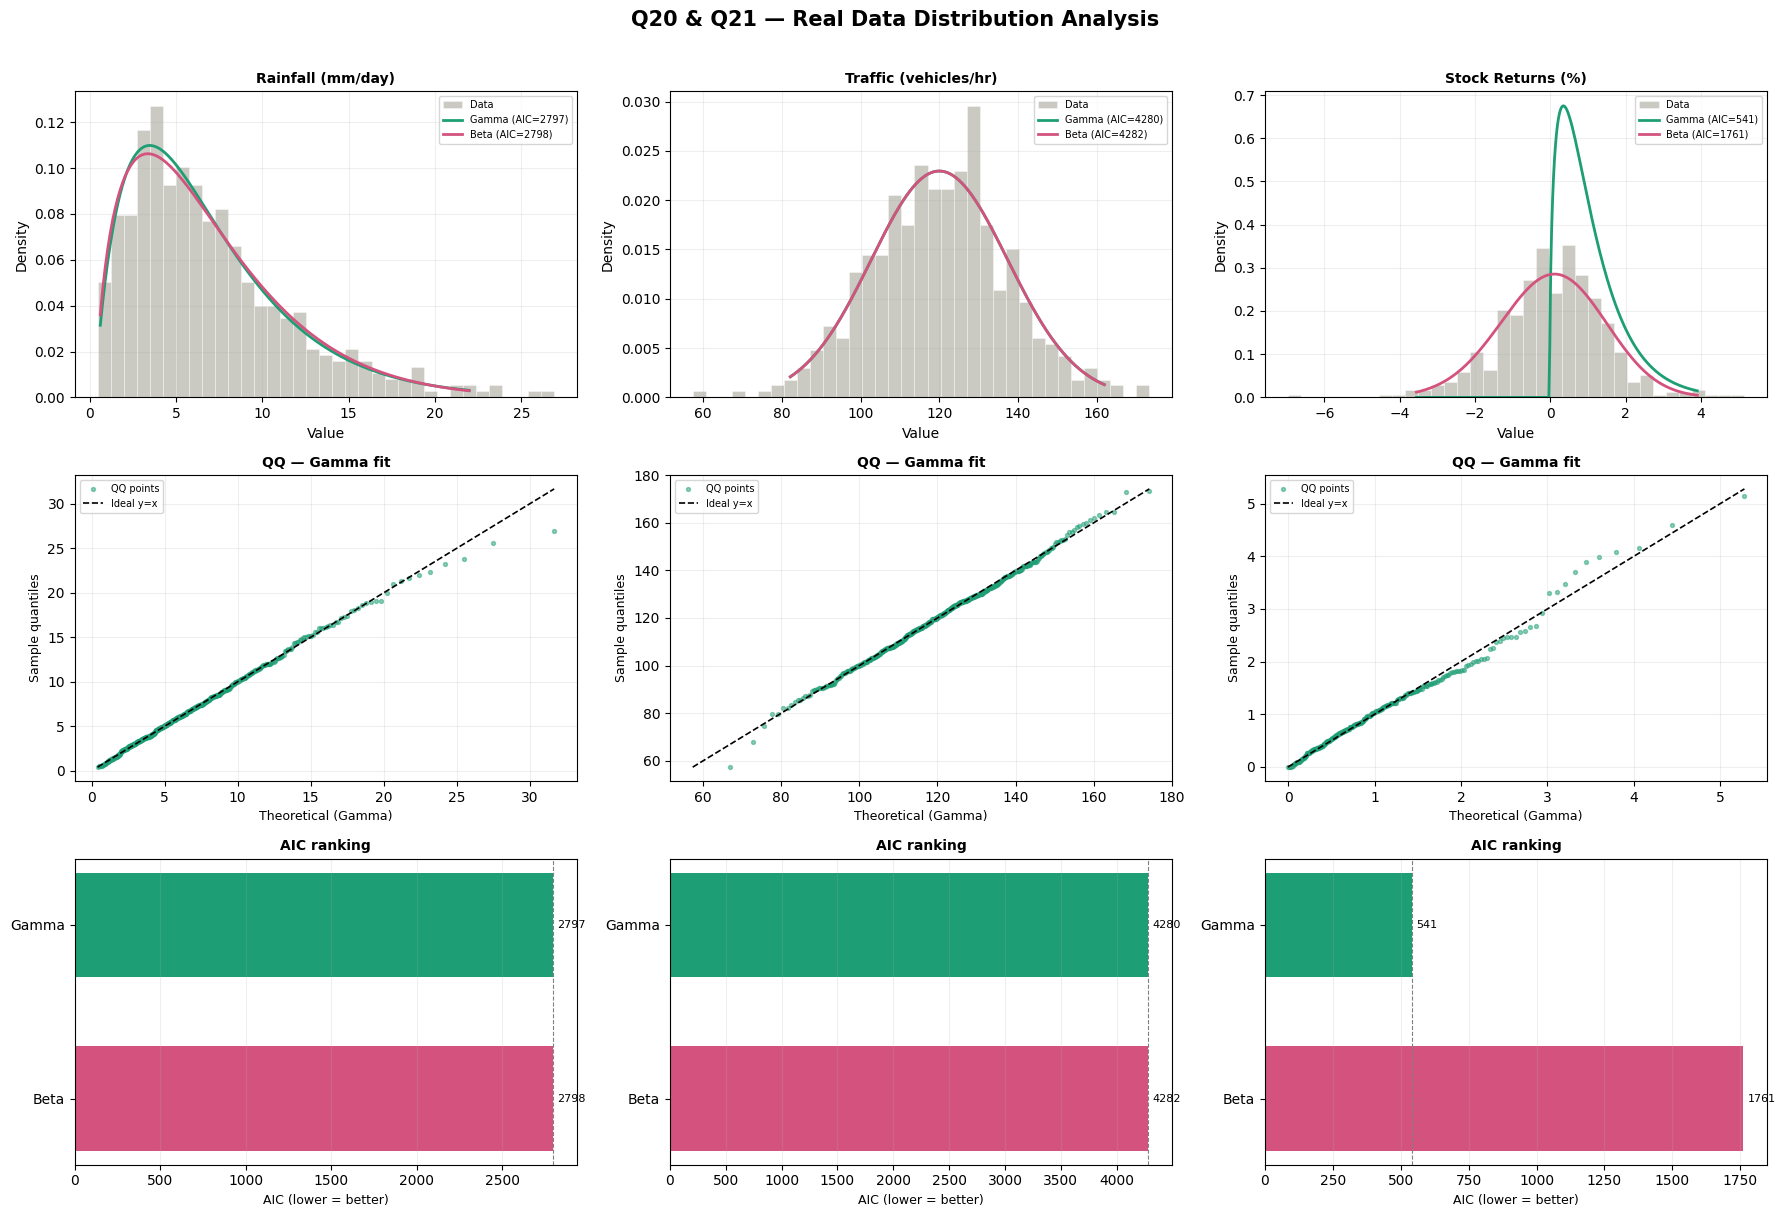

In [28]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Q20 & Q21 — Real Data Distribution Analysis", fontsize=15, fontweight='bold', y=1.01)

colors = {'Normal':'#378ADD', 'Log-normal':'#D85A30', 'Gamma':'#1D9E75',
          'Exponential':'#7F77DD', 'Weibull':'#BA7517', 'Beta':'#D4537E', 't-dist':'#5F5E5A'}

for col_idx, (name, data) in enumerate(datasets.items()):
    results = all_results[name]
    best    = results[0]
    top3    = results[:3]

    # ── Row 1: Histogram with fitted PDFs ─────────────────────────────────────
    ax_hist = fig.add_subplot(3, 3, col_idx + 1)
    ax_hist.hist(data, bins=35, density=True, color='#B4B2A9', edgecolor='white',
                 linewidth=0.4, alpha=0.7, label='Data')

    x = np.linspace(np.percentile(data, 1), np.percentile(data, 99), 300)
    for r in top3:
        dist   = CANDIDATES[r['dist']]
        params = r['params']
        try:
            y = dist.pdf(x, *params)
            ax_hist.plot(x, y, lw=2, color=colors[r['dist']],
                         label=f"{r['dist']} (AIC={r['aic']:.0f})")
        except Exception:
            pass

    ax_hist.set_title(name, fontsize=10, fontweight='bold')
    ax_hist.set_xlabel("Value"); ax_hist.set_ylabel("Density")
    ax_hist.legend(fontsize=7); ax_hist.grid(alpha=0.2)

    # ── Row 2: QQ plot for best fit ───────────────────────────────────────────
    ax_qq = fig.add_subplot(3, 3, col_idx + 4)
    dist_obj = CANDIDATES[best['dist']]
    params   = best['params']
    data_pos = data[data > 0] if best['dist'] in ('Log-normal','Gamma','Exponential','Weibull') else data
    n        = len(data_pos)
    probs    = (np.arange(1, n+1) - 0.5) / n
    theo_q   = dist_obj.ppf(probs, *params)
    emp_q    = np.sort(data_pos)

    ax_qq.scatter(theo_q, emp_q, s=8, alpha=0.5, color=colors[best['dist']], label='QQ points')
    lo, hi = min(theo_q.min(), emp_q.min()), max(theo_q.max(), emp_q.max())
    ax_qq.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='Ideal y=x')
    ax_qq.set_xlabel(f"Theoretical ({best['dist']})", fontsize=9)
    ax_qq.set_ylabel("Sample quantiles", fontsize=9)
    ax_qq.set_title(f"QQ — {best['dist']} fit", fontsize=10, fontweight='bold')
    ax_qq.legend(fontsize=7); ax_qq.grid(alpha=0.2)

    # ── Row 3: AIC comparison bar chart ──────────────────────────────────────
    ax_aic = fig.add_subplot(3, 3, col_idx + 7)
    names_r = [r['dist'] for r in results]
    aics_r  = [r['aic']  for r in results]
    bar_colors = [colors.get(n, '#888') for n in names_r]
    bars = ax_aic.barh(names_r, aics_r, color=bar_colors, edgecolor='none', height=0.6)
    ax_aic.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
    ax_aic.invert_yaxis()
    ax_aic.set_xlabel("AIC (lower = better)", fontsize=9)
    ax_aic.set_title("AIC ranking", fontsize=10, fontweight='bold')
    ax_aic.grid(axis='x', alpha=0.2)
    ax_aic.axvline(min(aics_r), color='gray', lw=0.8, linestyle='--')

plt.tight_layout()
plt.savefig("q20_q21_real_data_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ── Imports (no internet needed) ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, auc,
                              ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [30]:
# ══════════════════════════════════════════════════════════════
# STEP 1 — Build dataset (same as Q20, no internet)
# ══════════════════════════════════════════════════════════════
N = 500

rainfall = np.random.gamma(shape=2.0, scale=3.5, size=N)
traffic  = np.random.normal(loc=120,  scale=18,   size=N).clip(50, 220)
returns  = np.random.standard_t(df=5, size=N) * 1.2 + 0.05
humidity = np.random.uniform(30, 90, size=N)
wind     = np.random.gamma(shape=2.0, scale=4.0, size=N)

# Target: predict "high risk day" (1) vs "normal day" (0)
# High risk = heavy rain + low traffic + negative returns
risk_score = (0.4*rainfall - 0.008*traffic + 0.3*returns
              + 0.005*humidity - 0.02*wind
              + np.random.normal(0, 0.3, N))

y = (risk_score > np.percentile(risk_score, 55)).astype(int)

df = pd.DataFrame({
    'rainfall': rainfall,
    'traffic':  traffic,
    'returns':  returns,
    'humidity': humidity,
    'wind':     wind,
    'risk':     y
})

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['risk'].value_counts().rename({0:'Normal day', 1:'High-risk day'}))
print("\nFeature statistics:")
print(df.drop('risk', axis=1).describe().round(2))

Dataset shape: (500, 6)

Class distribution:
risk
Normal day       275
High-risk day    225
Name: count, dtype: int64

Feature statistics:
       rainfall  traffic  returns  humidity    wind
count    500.00   500.00   500.00    500.00  500.00
mean       6.94   120.14     0.04     59.48    8.47
std        4.70    17.40     1.40     17.14    6.02
min        0.46    57.35    -6.97     30.04    0.13
25%        3.52   107.73    -0.75     44.93    4.02
50%        5.90   120.50     0.08     58.07    7.05
75%        9.13   130.99     0.87     75.02   11.41
max       26.90   173.37     5.15     89.97   41.35


In [31]:
# ══════════════════════════════════════════════════════════════
# STEP 2 — Preprocess & split
# ══════════════════════════════════════════════════════════════
FEATURES = ['rainfall', 'traffic', 'returns', 'humidity', 'wind']
X = df[FEATURES].values
y = df['risk'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Positive class ratio — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

Train: 375 samples | Test: 125 samples
Positive class ratio — Train: 45.07% | Test: 44.80%


In [32]:
# ══════════════════════════════════════════════════════════════
# STEP 3 — Train 4 models
# ══════════════════════════════════════════════════════════════
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes':         GaussianNB(),
    'Decision Tree':       DecisionTreeClassifier(max_depth=4, random_state=42),
}

results = {}
print(f"\n{'Model':<25} {'CV Acc':>8} {'Test Acc':>10} {'F1':>8} {'AUC':>8}")
print("-" * 65)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        'model':    model,
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'test_acc': accuracy_score(y_test, y_pred),
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'fpr': fpr, 'tpr': tpr,
        'auc': roc_auc,
        'report':   classification_report(y_test, y_pred,
                        target_names=['Normal', 'High-risk'], output_dict=True)
    }
    print(f"{name:<25} {cv_scores.mean():.4f}±{cv_scores.std():.3f} "
          f"{results[name]['test_acc']:>10.4f} "
          f"{results[name]['report']['weighted avg']['f1-score']:>8.4f} "
          f"{roc_auc:>8.4f}")

best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\nBest model: {best_name}  (AUC = {results[best_name]['auc']:.4f})")


Model                       CV Acc   Test Acc       F1      AUC
-----------------------------------------------------------------
Logistic Regression       0.9440±0.023     0.9200   0.9191   0.9878
K-Nearest Neighbors       0.8693±0.016     0.8560   0.8523   0.9757
Naive Bayes               0.9093±0.037     0.9200   0.9194   0.9790
Decision Tree             0.9093±0.021     0.9440   0.9438   0.9429

Best model: Logistic Regression  (AUC = 0.9878)


In [33]:
# ══════════════════════════════════════════════════════════════
# STEP 4 — Detailed report for best model
# ══════════════════════════════════════════════════════════════
best = results[best_name]
print(f"\n{'='*50}")
print(f"Detailed Report — {best_name}")
print(f"{'='*50}")
print(classification_report(y_test, best['y_pred'],
      target_names=['Normal day', 'High-risk day']))


Detailed Report — Logistic Regression
               precision    recall  f1-score   support

   Normal day       0.88      0.99      0.93        69
High-risk day       0.98      0.84      0.90        56

     accuracy                           0.92       125
    macro avg       0.93      0.91      0.92       125
 weighted avg       0.93      0.92      0.92       125



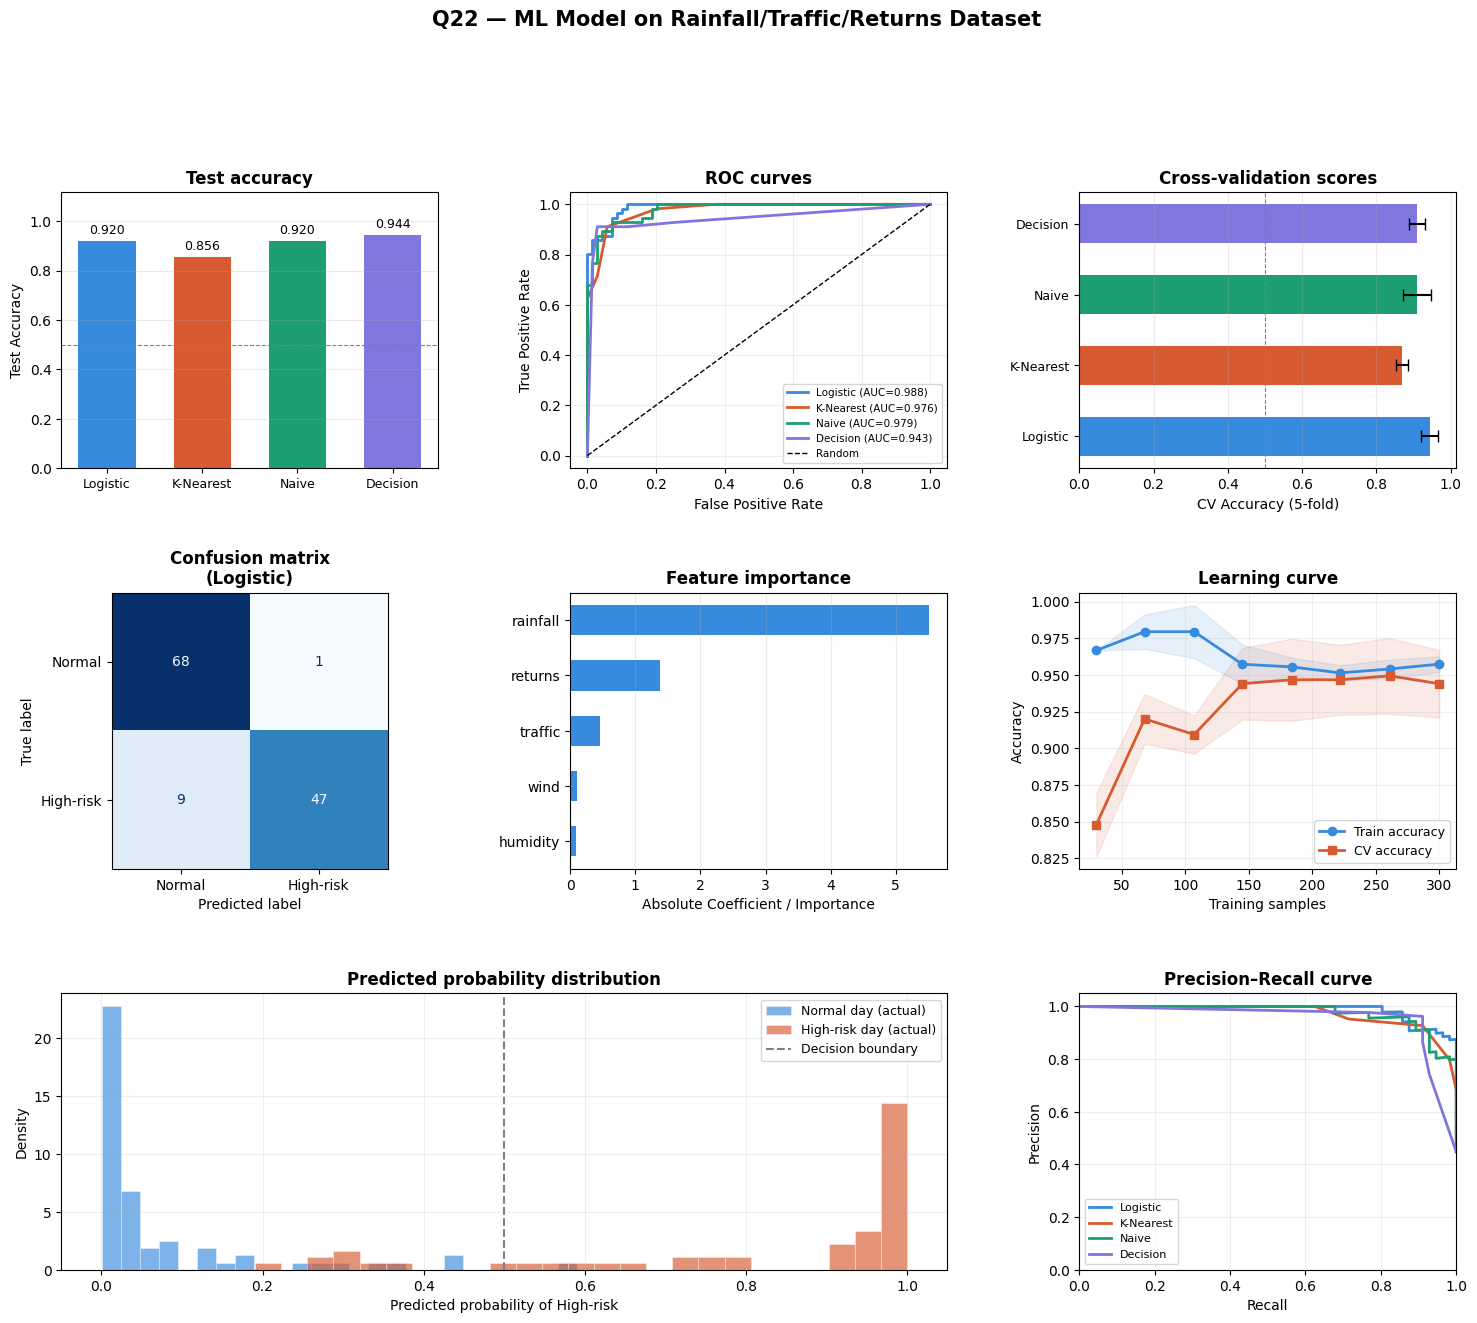

Saved: q22_ml_model.png


In [34]:
# ══════════════════════════════════════════════════════════════
# STEP 5 — Full visualisation (6 panels)
# ══════════════════════════════════════════════════════════════
COLORS = {
    'Logistic Regression': '#378ADD',
    'K-Nearest Neighbors': '#D85A30',
    'Naive Bayes':         '#1D9E75',
    'Decision Tree':       '#7F77DD',
}

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Q22 — ML Model on Rainfall/Traffic/Returns Dataset",
             fontsize=15, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Test accuracy bar chart ─────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
names_list = list(results.keys())
accs  = [results[n]['test_acc'] for n in names_list]
bars  = ax1.bar(range(len(names_list)), accs,
                color=[COLORS[n] for n in names_list], edgecolor='none', width=0.6)
ax1.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax1.set_xticks(range(len(names_list)))
ax1.set_xticklabels([n.split()[0] for n in names_list], fontsize=9)
ax1.set_ylabel("Test Accuracy"); ax1.set_title("Test accuracy", fontweight='bold')
ax1.set_ylim(0, 1.12); ax1.axhline(0.5, color='gray', lw=0.8, linestyle='--')
ax1.grid(axis='y', alpha=0.25)

# ── Panel 2: ROC curves all models ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for name, res in results.items():
    ax2.plot(res['fpr'], res['tpr'], lw=2, color=COLORS[name],
             label=f"{name.split()[0]} (AUC={res['auc']:.3f})")
ax2.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax2.set_xlabel("False Positive Rate"); ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC curves", fontweight='bold')
ax2.legend(fontsize=7.5); ax2.grid(alpha=0.2)

# ── Panel 3: CV scores with error bars ───────────────────────
ax3 = fig.add_subplot(gs[0, 2])
cv_means = [results[n]['cv_mean'] for n in names_list]
cv_stds  = [results[n]['cv_std']  for n in names_list]
ax3.barh(range(len(names_list)), cv_means,
         xerr=cv_stds, color=[COLORS[n] for n in names_list],
         edgecolor='none', height=0.55, capsize=4)
ax3.set_yticks(range(len(names_list)))
ax3.set_yticklabels([n.split()[0] for n in names_list], fontsize=9)
ax3.set_xlabel("CV Accuracy (5-fold)")
ax3.set_title("Cross-validation scores", fontweight='bold')
ax3.axvline(0.5, color='gray', lw=0.8, linestyle='--')
ax3.grid(axis='x', alpha=0.25)

# ── Panel 4: Confusion matrix — best model ────────────────────
ax4 = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal', 'High-risk'])
disp.plot(ax=ax4, colorbar=False, cmap='Blues')
ax4.set_title(f"Confusion matrix\n({best_name.split()[0]})", fontweight='bold')

# ── Panel 5: Feature importance ──────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
if hasattr(results[best_name]['model'], 'coef_'):
    importance = np.abs(results[best_name]['model'].coef_[0])
elif hasattr(results[best_name]['model'], 'feature_importances_'):
    importance = results[best_name]['model'].feature_importances_
else:
    lr_model = results['Logistic Regression']['model']
    importance = np.abs(lr_model.coef_[0])

sorted_idx = np.argsort(importance)
ax5.barh([FEATURES[i] for i in sorted_idx], importance[sorted_idx],
          color=COLORS[best_name], edgecolor='none', height=0.55)
ax5.set_xlabel("Absolute Coefficient / Importance")
ax5.set_title("Feature importance", fontweight='bold')
ax5.grid(axis='x', alpha=0.25)

# ── Panel 6: Learning curve — best model ─────────────────────
ax6 = fig.add_subplot(gs[1, 2])
train_sizes, train_scores, val_scores = learning_curve(
    results[best_name]['model'], X_train, y_train,
    cv=5, train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='accuracy', n_jobs=-1
)
ax6.plot(train_sizes, train_scores.mean(axis=1), 'o-',
         color='#378ADD', lw=2, label='Train accuracy')
ax6.fill_between(train_sizes,
                 train_scores.mean(1)-train_scores.std(1),
                 train_scores.mean(1)+train_scores.std(1),
                 alpha=0.12, color='#378ADD')
ax6.plot(train_sizes, val_scores.mean(axis=1), 's-',
         color='#D85A30', lw=2, label='CV accuracy')
ax6.fill_between(train_sizes,
                 val_scores.mean(1)-val_scores.std(1),
                 val_scores.mean(1)+val_scores.std(1),
                 alpha=0.12, color='#D85A30')
ax6.set_xlabel("Training samples"); ax6.set_ylabel("Accuracy")
ax6.set_title("Learning curve", fontweight='bold')
ax6.legend(fontsize=9); ax6.grid(alpha=0.2)

# ── Panel 7: Prediction probability histogram ─────────────────
ax7 = fig.add_subplot(gs[2, :2])
proba = best['y_proba']
ax7.hist(proba[y_test==0], bins=25, density=True, alpha=0.65,
         color='#378ADD', label='Normal day (actual)', edgecolor='white', lw=0.4)
ax7.hist(proba[y_test==1], bins=25, density=True, alpha=0.65,
         color='#D85A30', label='High-risk day (actual)', edgecolor='white', lw=0.4)
ax7.axvline(0.5, color='gray', lw=1.5, linestyle='--', label='Decision boundary')
ax7.set_xlabel("Predicted probability of High-risk")
ax7.set_ylabel("Density")
ax7.set_title("Predicted probability distribution", fontweight='bold')
ax7.legend(fontsize=9); ax7.grid(alpha=0.2)

# ── Panel 8: Precision–Recall tradeoff ───────────────────────
from sklearn.metrics import precision_recall_curve
ax8 = fig.add_subplot(gs[2, 2])
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    ax8.plot(rec, prec, lw=2, color=COLORS[name], label=name.split()[0])
ax8.set_xlabel("Recall"); ax8.set_ylabel("Precision")
ax8.set_title("Precision–Recall curve", fontweight='bold')
ax8.legend(fontsize=8); ax8.grid(alpha=0.2)
ax8.set_xlim(0, 1); ax8.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("q22_ml_model.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: q22_ml_model.png")